# Step 2b — Advanced State Competitiveness Indicators
**Objective:** Build on Step 2 with advanced competitiveness metrics — revealing not just what states trade and with whom, but how competitive they are structurally, how concentrated their product base is, and what their logistical profile looks like.

**Prerequisites:** Step 2 must have been run first. This notebook reuses `df_state` and other dataframes from that session, or re-queries them where needed.

This notebook covers:
1. Revealed Comparative Advantage (RCA) by State and SH2 Sector
2. Export Specialisation Index by State
3. Product Concentration Index by State (HHI at product level)
4. Export Frequency — Number of Shipments by State
5. Average Shipment Size by State (kg and USD per shipment)
6. Logistics Profile Summary — Bulk vs High-Frequency Exporters
7. Key Findings

## Setup

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv
from scipy import stats

dotenv_path = Path(r"C:\Users\e_koh\Downloads\State Analysis\brazil-state-trade-analysis\.env")
load_dotenv(dotenv_path, override=True)

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected to database successfully")

## Data capped at 2025 — 2026 contains only partial year data
MAX_YEAR = 2025

## Re-query state totals in case Step 2 session is not active
query_state_totals = f"""
    SELECT u.nome_estado AS state,
           u.nome_regiao AS region,
           u.sigla AS uf,
           COALESCE(e.exports_usd, 0) AS exports_usd,
           COALESCE(i.imports_usd, 0) AS imports_usd
    FROM uf u
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS exports_usd
        FROM exp WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) e ON e."SG_UF_NCM" = u.sigla
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS imports_usd
        FROM imp WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) i ON i."SG_UF_NCM" = u.sigla
    WHERE COALESCE(e.exports_usd, 0) > 0 OR COALESCE(i.imports_usd, 0) > 0
    ORDER BY exports_usd DESC
"""
df_state = pd.read_sql(query_state_totals, engine)
## Remove non-geographic entries — these are not real states and distort all analyses
df_state = df_state[~df_state['state'].isin(['Não Declarada', 'Exterior'])]
df_state['exports_usd_bn'] = (df_state['exports_usd'] / 1e9).round(2)
df_state['imports_usd_bn'] = (df_state['imports_usd'] / 1e9).round(2)
print(f"State totals loaded: {len(df_state)} states")

Connected to database successfully
State totals loaded: 27 states


## 2b.1 — Revealed Comparative Advantage (RCA) by State and SH2 Sector
The RCA index measures whether a state exports a given sector more intensively than Brazil does nationally.

**Formula:** RCA = (State share in sector) / (National share in sector)

- RCA > 1 → the state has a comparative advantage in that sector
- RCA < 1 → the state is less specialised in that sector than the national average

Calculated at SH2 sector level for all states in MAX_YEAR.

### 2b.1.1 — Revealed Comparative Advantage (RCA) by Top 10 States and Top 10 SH2 Sector

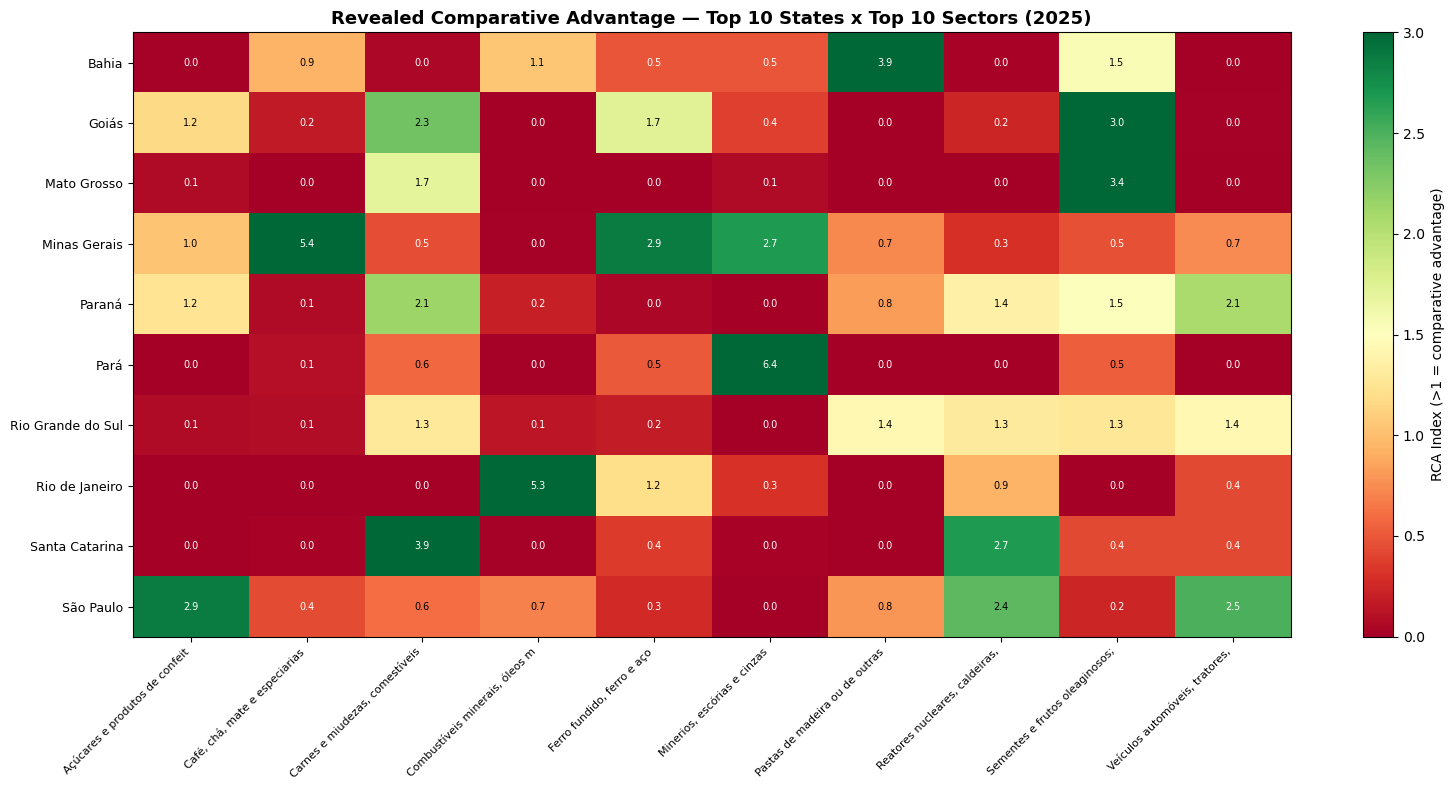


Top 5 sectors by RCA per state (2025) — sectors where RCA > 1 indicate comparative advantage

  São Paulo
    Aeronaves e aparelhos espaciais, e suas parte RCA=4.65  $4.54bn
    Estanho e suas obras                          RCA=4.41  $0.26bn
    Fibras sintéticas ou artificiais, descontínua RCA=4.18  $0.05bn
    Produtos para fotografia e cinematografia     RCA=4.07  $0.03bn
    Tapetes e outros revestimentos para pisos (pa RCA=4.01  $0.02bn

  Rio de Janeiro
    Combustíveis minerais, óleos minerais e produ RCA=5.30  $40.79bn
    Níquel e suas obras                           RCA=2.57  $0.02bn
    Embarcações e estruturas flutuantes           RCA=1.97  $0.02bn
    Obras de espartaria ou de cestaria            RCA=1.57  $0.00bn
    Borracha e suas obras                         RCA=1.26  $0.34bn

  Minas Gerais
    Zinco e suas obras                            RCA=7.32  $0.19bn
    Outros metais comuns; ceramais (cermets); obr RCA=6.96  $0.20bn
    Café, chá, mate e especiarias         

In [24]:
## Exports by state and SH2 sector
query_rca = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.codigo_sh2,
           s.descricao_sh2 AS sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado, s.codigo_sh2, s.descricao_sh2
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_rca_raw = pd.read_sql(query_rca, engine)

## Remove non-geographic entries carried over from df_rca_raw
df_rca_raw = df_rca_raw[~df_rca_raw['state'].isin(['Não Declarada', 'Exterior'])]

## State total exports
state_totals = df_rca_raw.groupby('uf')['exports_usd'].sum().rename('state_total')
df_rca_raw   = df_rca_raw.join(state_totals, on='uf')

## National total exports per sector
national_sector = df_rca_raw.groupby('sector')['exports_usd'].sum().rename('national_sector')
df_rca_raw      = df_rca_raw.join(national_sector, on='sector')

## National total exports
national_total = df_rca_raw['exports_usd'].sum()

## RCA = (state_sector / state_total) / (national_sector / national_total)
df_rca_raw['state_sector_share']    = df_rca_raw['exports_usd']    / df_rca_raw['state_total']
df_rca_raw['national_sector_share'] = df_rca_raw['national_sector'] / national_total
df_rca_raw['rca'] = (df_rca_raw['state_sector_share'] / df_rca_raw['national_sector_share']).round(3)

## Focus on top 10 exporting states and top 10 sectors by national value
top10_states  = df_state.head(10)['state'].tolist()
top10_sectors = (
    df_rca_raw.groupby('sector')['exports_usd']
    .sum().nlargest(10).index.tolist()
)

df_rca_heat = df_rca_raw[
    df_rca_raw['state'].isin(top10_states) &
    df_rca_raw['sector'].isin(top10_sectors)
].pivot(index='state', columns='sector', values='rca').fillna(0)

## Shorten sector labels for readability
df_rca_heat.columns = [str(c)[:30] for c in df_rca_heat.columns]

## Heatmap
fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(df_rca_heat.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=3)
ax.set_xticks(range(len(df_rca_heat.columns)))
ax.set_xticklabels(df_rca_heat.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(df_rca_heat.index)))
ax.set_yticklabels(df_rca_heat.index, fontsize=9)

## Annotate cells with RCA value
for i in range(len(df_rca_heat.index)):
    for j in range(len(df_rca_heat.columns)):
        val = df_rca_heat.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=7,
                color='black' if 0.5 < val < 2.5 else 'white')

plt.colorbar(im, ax=ax, label='RCA Index (>1 = comparative advantage)')
ax.set_title(f'Revealed Comparative Advantage — Top 10 States x Top 10 Sectors ({MAX_YEAR})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2b1_rca_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Print top 5 RCA sectors per state
print(f"\nTop 5 sectors by RCA per state ({MAX_YEAR}) — sectors where RCA > 1 indicate comparative advantage")
for state in top10_states:
    subset = df_rca_raw[
        (df_rca_raw['state'] == state) & (df_rca_raw['rca'] > 1)
    ].nlargest(5, 'rca')[['sector', 'rca', 'exports_usd']]
    subset['exports_usd_bn'] = (subset['exports_usd'] / 1e9).round(2)
    print(f"\n  {state}")
    if subset.empty:
        print("    No sectors with RCA > 1")
    else:
        for _, row in subset.iterrows():
            print(f"    {str(row['sector'])[:45]:<45} RCA={row['rca']:.2f}  ${row['exports_usd_bn']:.2f}bn")

# RCA Analysis — Key Findings (2025)

---

## Overall Pattern

The RCA results reveal a clear structural divide in Brazil's state-level export competitiveness. States in the Centro-Oeste and Norte regions show strong comparative advantages in agricultural commodities and mineral extraction, while Sul and Sudeste states show advantages in industrial and manufactured goods — with important exceptions at the state level.

---

## State-by-State Findings

### São Paulo
Comparative advantage concentrated in aerospace (RCA 4.53, \\$4.54bn), which is entirely driven by Embraer. The remaining top RCA sectors are niche — tin works, synthetic fibres, photographic products — and negligible in value. São Paulo's export strength is broad rather than deep in any single sector, consistent with its low HHI (0.06).

---

### Rio de Janeiro
The clearest single-sector dominance in the dataset. Mineral fuels and oils (RCA 5.18, \\$40.79bn) account for the overwhelming majority of the state's exports. The next four RCA sectors are either negligible in value or structurally unrelated. This confirms the regression outlier — Rio de Janeiro's high shipment frequency coexists with extreme product concentration driven by oil and gas.

> ⚠️ *Rio de Janeiro's RCA profile is dominated by a single sector. This concentration carries significant exposure to commodity price cycles and energy transition risk.*

---

### Minas Gerais
Comparative advantage spread across metals and agriculture. Coffee (RCA 5.48, \\$11.29bn), iron and steel (RCA 2.88, \\$4.67bn) and precious stones (RCA 3.49, \\$3.30bn) are all material in value. Zinc and cermets show high RCA but negligible export value — specialist niches rather than structural strengths.

---

### Mato Grosso
The most commodity-concentrated agricultural profile in the dataset. Soybeans and oilseeds (RCA 3.40, \\$13.17bn), cereals (RCA 5.63, \\$4.67bn) and cotton (RCA 7.16, \\$3.13bn) dominate. Every top RCA sector is agricultural. This state is Brazil's agricultural export engine and is structurally exposed to global commodity price cycles.

---

### Pará
Mineral and extractive dominance. Ores and slag (RCA 6.45, \\$15.73bn) is the value anchor, supported by inorganic chemicals (RCA 6.47, \\$2.30bn) and aluminium (RCA 5.25, \\$0.64bn). The iron ore and aluminium profile reflects the Carajás mining complex. High RCA across multiple extractive categories but all within the same commodity cluster.

---

### Paraná
The most striking gap between RCA rank and export value in the dataset. The top RCA sectors — silk (RCA 10.30), explosives (RCA 5.71), milling products (RCA 5.39) — are all extremely high RCA but negligible in export value (under \\$0.15bn each). Paraná's true export strength lies in sectors not captured in the top 5 by RCA, suggesting the state has structural advantages in niche industrial products that do not yet translate into large export volumes.

> ⚠️ *Paraná's RCA top 5 requires caution in interpretation — high RCA on low-value sectors may reflect small denominators rather than genuine structural competitiveness.*

---

### Rio Grande do Sul
The highest individual RCA values in the dataset. Furs (RCA 16.10), wool (RCA 14.57) and tobacco (RCA 14.55, \\$3.05bn) dominate the top 5. Tobacco is the only sector with material export value. Footwear (RCA 8.36, \\$0.55bn) is the most industrially significant comparative advantage. The state's export base is diversified but several of its strongest RCA sectors are in declining global industries (tobacco, fur).

---

### Goiás
Agricultural comparative advantages in soybeans (RCA 3.02, \\$5.22bn) and cereals (RCA 2.72, \\$1.01bn) are the value anchors. Leather (RCA 3.11) reflects the state's agribusiness integration. A broadly agricultural profile similar to Mato Grosso but with lower concentration.

---

### Santa Catarina
The most striking textile RCA profile in Brazil. Specialised fabrics (RCA 18.99), knitted fabrics (RCA 16.18), clothing (RCA 13.15) and vessels (RCA 13.65) all appear in the top 5. However all four textile sectors have negligible export values (under \\$0.06bn each). The vessels sector likely reflects small-scale boat manufacturing. Santa Catarina's true export strength lies elsewhere — its low HHI (0.15) and high shipment frequency suggest broad diversification not captured in the top 5 RCA sectors.

---

### Bahia
The highest single RCA value in the dataset: other vegetable fibres (RCA 28.67, \\$0.05bn). Cocoa (RCA 20.44, \\$0.55bn) is the most economically significant comparative advantage and reflects Bahia's historical position as Brazil's cocoa-producing region. Organic chemicals (RCA 5.57, \\$0.32bn) is the only industrial sector in the top 5.

---

## Cross-Cutting Observations

**High RCA ≠ high export value** — Paraná, Santa Catarina and Rio Grande do Sul all show extremely high RCA values in sectors with negligible export volumes. This is a mathematical artefact of the RCA formula when national shares are very small. These results should be interpreted cautiously.

**The commodity-industrial divide is visible but not clean** — Mato Grosso and Pará are unambiguously commodity-driven. São Paulo is unambiguously industrial. But states like Minas Gerais, Paraná and Bahia show hybrid profiles that do not fit neatly into either category.

> ⚠️ *Requires further investigation (Step 5): Do the high-RCA low-value sectors in Paraná, Santa Catarina and Rio Grande do Sul represent genuine emerging competitiveness or statistical artefacts of small national market shares?*


### 2b.1.2 — Revealed Comparative Advantage (RCA) by Lowest 10 States and Top 10 SH2 Sector

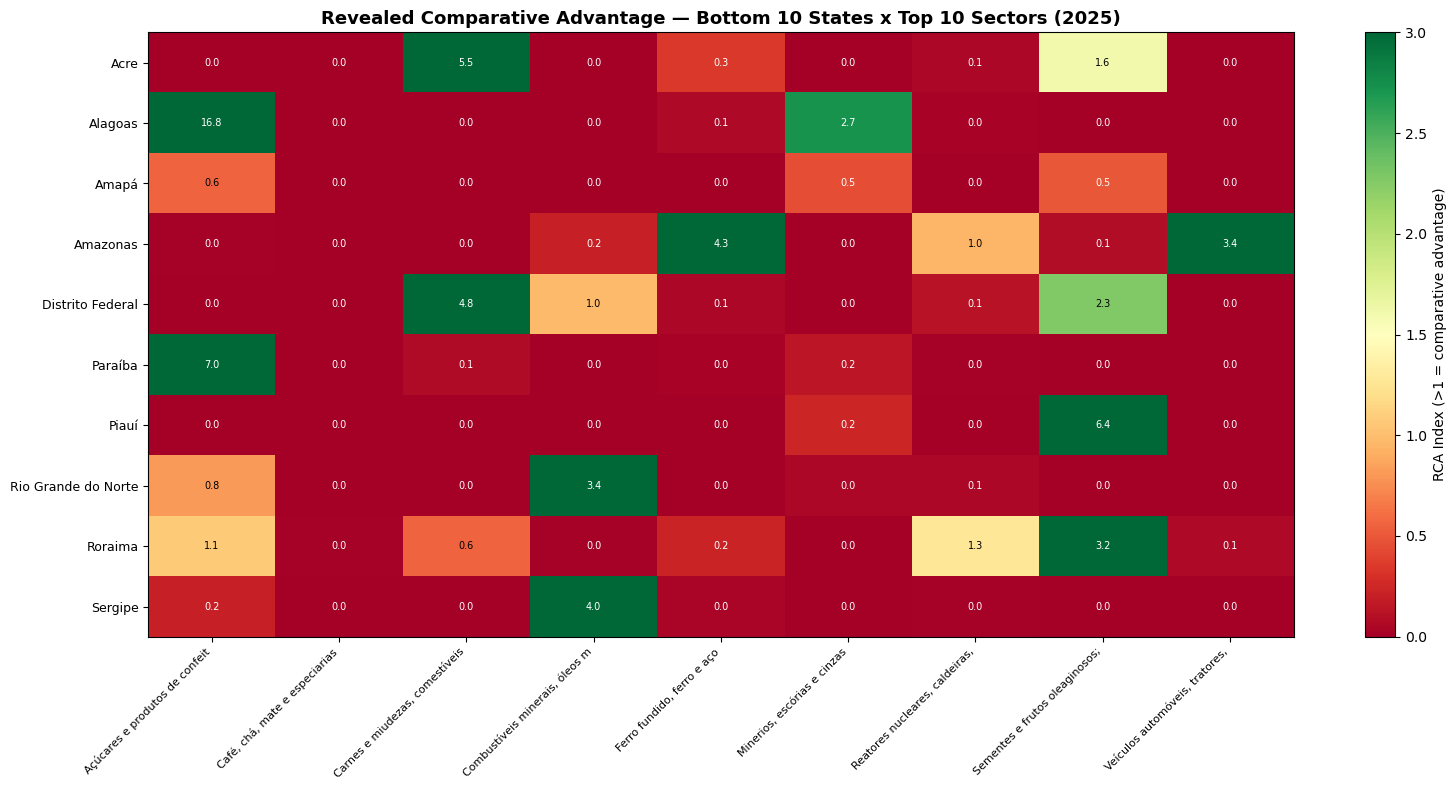


Top 5 sectors by RCA — Bottom 10 exporting states (2025)

  Piauí
    Leite e lacticínios; ovos de aves; mel natura RCA=15.63  $0.02bn
    Sementes e frutos oleaginosos; grãos, semente RCA=6.42  $0.99bn
    Gorduras e óleos animais ou vegetais; produto RCA=3.83  $0.04bn
    Peixes e crustáceos, moluscos e outros invert RCA=2.95  $0.00bn
    Algodão                                       RCA=2.47  $0.04bn

  Rio Grande do Norte
    Frutas; cascas de frutos cítricos e de melões RCA=59.64  $0.27bn
    Peixes e crustáceos, moluscos e outros invert RCA=21.54  $0.03bn
    Sal; enxofre; terras e pedras; gesso, cal e c RCA=10.12  $0.03bn
    Outros produtos de origem animal, não especif RCA=5.73  $0.01bn
    Pérolas naturais ou cultivadas, pedras precio RCA=4.12  $0.10bn

  Amazonas
    Brinquedos, jogos, artigos para divertimento  RCA=42.81  $0.01bn
    Preparações alimentícias diversas             RCA=38.18  $0.21bn
    Ferramentas, artefatos de cutelaria e talhere RCA=24.16  $0.03bn
    Obr

In [25]:
## RCA heatmap for the 10 lowest exporting states
## Uses df_rca_raw already computed above — no additional query needed

bottom10_states = df_state.tail(10)['state'].tolist()

df_rca_heat_bottom = df_rca_raw[
    df_rca_raw['state'].isin(bottom10_states) &
    df_rca_raw['sector'].isin(top10_sectors)
].pivot(index='state', columns='sector', values='rca').fillna(0)

df_rca_heat_bottom.columns = [str(c)[:30] for c in df_rca_heat_bottom.columns]

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(df_rca_heat_bottom.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=3)
ax.set_xticks(range(len(df_rca_heat_bottom.columns)))
ax.set_xticklabels(df_rca_heat_bottom.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(df_rca_heat_bottom.index)))
ax.set_yticklabels(df_rca_heat_bottom.index, fontsize=9)

for i in range(len(df_rca_heat_bottom.index)):
    for j in range(len(df_rca_heat_bottom.columns)):
        val = df_rca_heat_bottom.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=7,
                color='black' if 0.5 < val < 2.5 else 'white')

plt.colorbar(im, ax=ax, label='RCA Index (>1 = comparative advantage)')
ax.set_title(f'Revealed Comparative Advantage — Bottom 10 States x Top 10 Sectors ({MAX_YEAR})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2b1b_rca_heatmap_bottom10.png', dpi=150, bbox_inches='tight')
plt.show()

## Print top 5 RCA sectors per state for bottom 10
print(f"\nTop 5 sectors by RCA — Bottom 10 exporting states ({MAX_YEAR})")
for state in bottom10_states:
    subset = df_rca_raw[
        (df_rca_raw['state'] == state) & (df_rca_raw['rca'] > 1)
    ].nlargest(5, 'rca')[['sector', 'rca', 'exports_usd']]
    subset['exports_usd_bn'] = (subset['exports_usd'] / 1e9).round(2)
    print(f"\n  {state}")
    if subset.empty:
        print("    No sectors with RCA > 1")
    else:
        for _, row in subset.iterrows():
            print(f"    {str(row['sector'])[:45]:<45} RCA={row['rca']:.2f}  ${row['exports_usd_bn']:.2f}bn")

# RCA Analysis — Bottom 10 Exporting States (2025)

---

## Overall Pattern

The bottom 10 exporting states present a structurally different picture from the top 10. Comparative advantages are overwhelmingly concentrated in food products, natural resources and niche agricultural processing — with export values that are negligible in national terms. The recurring theme across this group is **high RCA combined with very low absolute value**, which reflects localised production strengths that have not yet scaled into meaningful export volumes.

A key methodological note: RCA values in this group are significantly higher than in the top 10 states — values above 10, 20 and even 100 appear frequently. This is partly a mathematical consequence of very small national market shares in the denominator, which amplifies the RCA ratio. These extreme values should be interpreted with caution.

---

## State-by-State Findings

### Piauí
A predominantly agricultural profile driven by oilseeds and soybeans (RCA 6.45, \\$0.99bn) — the highest absolute export value in the bottom 10 after Rio Grande do Norte's fruit sector and Alagoas's sugar. Dairy products and eggs lead the RCA ranking (RCA 15.73) but with negligible export value (\\$0.02bn). Cotton (RCA 2.49) and vegetable oils (RCA 3.85) complete an agricultural profile typical of the western Nordeste cerrado expansion. Piauí is part of the MATOPIBA agricultural frontier (Maranhão, Tocantins, Piauí, Bahia) — soybean exports reflect this recent land use transformation rather than a long-established export base.

---

### Rio Grande do Norte
Fruit exports dominate with an RCA of 60.03 (\\$0.27bn) — the highest value-backed RCA in this group. Fish and crustaceans (RCA 21.68) and salt and mineral earths (RCA 10.11) reflect the state's coastal and mineral geography. Precious stones (RCA 4.14, \\$0.10bn) is a secondary strength. The export base is narrow and geographically determined.

---

### Amazonas
The most surprising profile in the bottom 10. Toys and games (RCA 43.01) and miscellaneous food preparations (RCA 38.44, \\$0.21bn) top the list, reflecting the Zona Franca de Manaus (Manaus Free Trade Zone) industrial cluster. Cutlery and tools (RCA 24.32) also reflects manufacturing activity in Manaus. Despite these high RCA values the absolute export volumes remain small — the Free Trade Zone is primarily import-oriented and domestically focused rather than an export platform.

> ⚠️ *Amazonas's RCA profile reflects the Zona Franca de Manaus rather than natural resource endowments. Its export competitive advantages are structurally dependent on the continuation of the free trade zone regime.*

---

### Alagoas
Sugar and confectionery dominates (RCA 16.91, \\$0.57bn) — the highest absolute export value in this group after Rio Grande do Norte's fruit sector. Ores and slag (RCA 2.73, \\$0.23bn) is secondary. The state has only four sectors with RCA > 1, the fewest in this group, indicating extremely narrow export specialisation.

---

### Sergipe
Prepared vegetable and fruit products lead (RCA 27.19, \\$0.13bn). Mineral fuels (RCA 3.89, \\$0.28bn) is the highest absolute value sector — Sergipe has onshore oil production that does not dominate the RCA ranking but is the largest contributor to export revenue. A mixed profile of food processing and energy extraction.

---

### Distrito Federal
The weakest export profile in the bottom 10. The top RCA sectors — prepared meats and fish (RCA 14.01), basketry (RCA 11.84), toys (RCA 7.59) — are all negligible in export value (under \\$0.02bn each). Meats (RCA 4.82, \\$0.13bn) is the only sector with material value. The Federal District is an administrative and services centre with no meaningful goods export base, which makes its presence in this analysis largely nominal.

---

### Roraima
The highest single RCA value in the entire dataset: cereal-based preparations (RCA 81.55, \\$0.02bn). Despite the extreme RCA value the export volume is negligible. Vegetable oils (RCA 17.21, \\$0.04bn) and horticultural products (RCA 14.86, \\$0.01bn) complete a primarily subsistence and small-scale agricultural profile. Pharmaceuticals (RCA 5.96) is unexpected and likely reflects re-exports rather than domestic production.

> ⚠️ *Roraima's extreme RCA values (81.55) are almost certainly a mathematical artefact of very small national market shares in these categories rather than genuine structural competitiveness.*

---

### Paraíba
The highest RCA value across both the top 10 and bottom 10 groups: footwear (RCA 100.97, \\$0.05bn). Despite the extreme RCA the export value is minimal. Salt and mineral earths (RCA 30.31) and prepared fruit products (RCA 19.91, \\$0.04bn) follow. The footwear RCA likely reflects a small but highly specialised local industry — Paraíba has a documented footwear manufacturing cluster in Campina Grande — but it has not yet scaled into a nationally significant export sector.

> ⚠️ *Paraíba's footwear RCA of 100.97 is the highest in the entire dataset but corresponds to only \\$0.05bn in exports. This warrants investigation into whether the sector has growth potential or remains structurally constrained by scale.*

---

### Amapá
Timber dominates (RCA 54.90, \\$0.07bn), reflecting the state's Amazon forest geography. Miscellaneous food preparations (RCA 21.32) and prepared horticultural products (RCA 11.54) follow. The profile is entirely natural resource and primary processing driven with no industrial sectors appearing in the top 5.

---

### Acre
Fruit (RCA 31.45, \\$0.01bn) and animal products (RCA 21.47) lead, followed by live animals (RCA 15.27) and timber (RCA 5.50). Meats (RCA 5.58, \\$0.05bn) is the largest export by value. Acre's profile is entirely primary — livestock, timber and forest products. The lowest shipment count in the dataset (745) confirms this is Brazil's least trade-active state.

---

## Cross-Cutting Observations

**The value-RCA disconnect is more extreme in the bottom 10 than the top 10.** Values above RCA 20 appear in nearly every state in this group, but in most cases the corresponding export value is under \\$0.05bn. This confirms that the bottom 10 states have localised production specialisations that have not scaled into nationally significant export volumes.

**Food processing and primary agriculture dominate universally.** Every state in the bottom 10 has at least one food-related sector in its top 5 RCA. This is consistent with the Norte and Nordeste regional profiles identified in Step 2 — these states have not yet developed the industrial export base that characterises the Sul and Sudeste.

**Amazonas is the only state with an industrial RCA profile**, driven entirely by the Zona Franca de Manaus. It is structurally distinct from every other state in this group.

**The Distrito Federal should arguably be excluded from state-level export competitiveness analysis** — it is an administrative capital with no meaningful goods export base and its presence in the bottom 10 is structural rather than indicative of underperformance.

| State | Highest RCA | Highest Value Sector | Profile |
|---|---|---|---|
| Piauí | Dairy (15.7) | Oilseeds (\\$0.99bn) | MATOPIBA agricultural frontier |
| Rio Grande do Norte | Fruits (60.0) | Fruits (\\$0.27bn) | Agri-coastal |
| Amazonas | Toys (43.0) | Food preparations (\\$0.21bn) | Free Trade Zone industrial |
| Alagoas | Sugar (16.9) | Sugar (\\$0.57bn) | Monoculture agricultural |
| Sergipe | Vegetable preps (27.2) | Mineral fuels (\\$0.28bn) | Mixed food/energy |
| Distrito Federal | Meat preps (14.0) | Meats (\\$0.13bn) | Administrative — minimal export base |
| Roraima | Cereal preps (81.6) | Vegetable oils (\\$0.04bn) | Subsistence agricultural |
| Paraíba | Footwear (101.0) | Footwear (\\$0.05bn) | Niche manufacturing |
| Amapá | Timber (54.9) | Timber (\\$0.07bn) | Natural resource extraction |
| Acre | Fruits (31.5) | Meats (\\$0.05bn) | Primary livestock/forest |

> ⚠️ *Requires further investigation: Paraíba's footwear cluster (RCA 100.97) and Amazonas's Zona Franca manufacturing profile are the two most analytically interesting findings in this group. Both warrant dedicated follow-up to understand whether these represent scalable competitive advantages or structurally constrained niches.*


## 2b.2 — Export Specialisation Index by State
The Export Specialisation Index measures the degree to which a state's export basket is concentrated in a few sectors relative to the national average. A high index means the state exports a narrow range of products. A low index means its export mix mirrors Brazil's national mix.

**Formula:** ESI = sum of |state_sector_share - national_sector_share| for all sectors

Range: 0 (identical to national mix) to 2 (completely different from national mix).

C:\Users\e_koh\AppData\Local\Temp\ipykernel_21180\1016213126.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['state_sector_share'] - x['national_sector_share']).abs().sum())


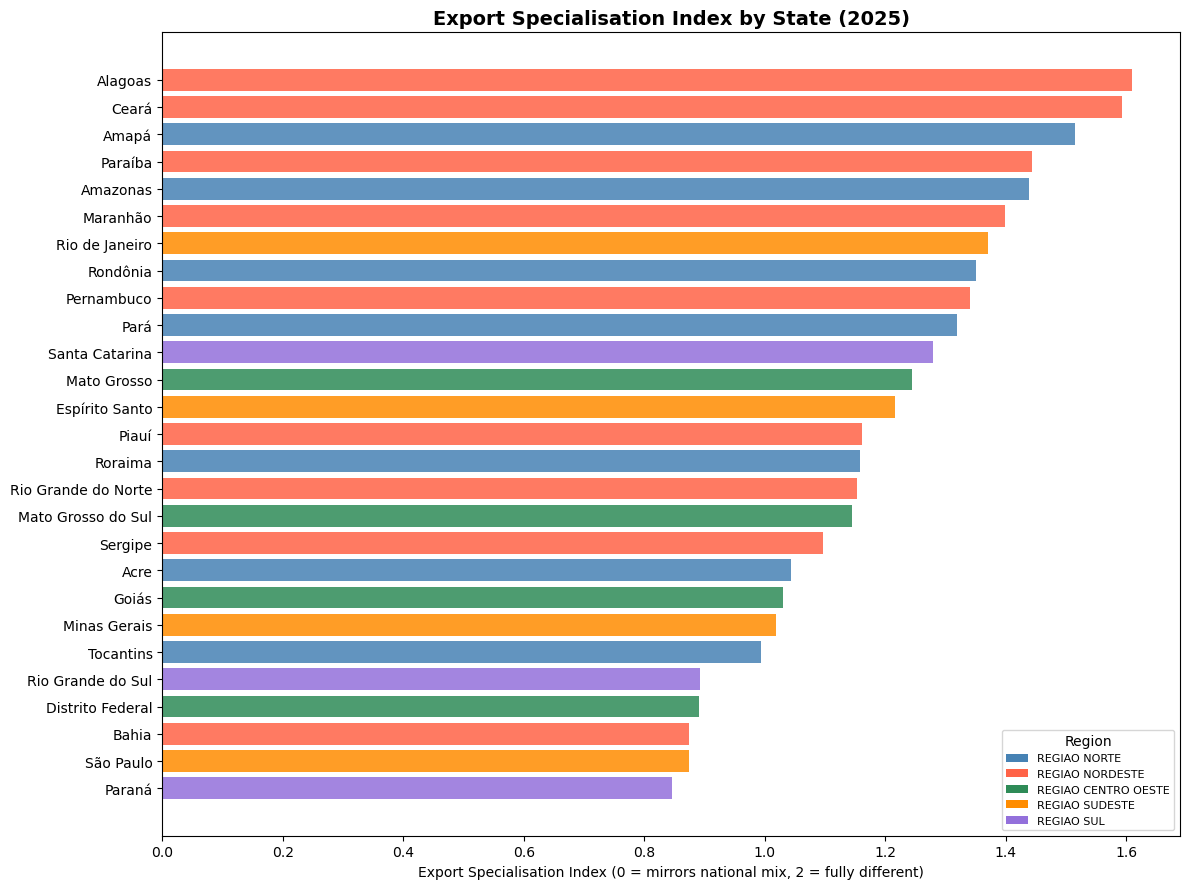


Export Specialisation Index by state (2025)
Higher ESI = more specialised / less diversified relative to national mix
              state              region  exports_usd_bn    esi
            Alagoas     REGIAO NORDESTE            0.82 1.6084
              Ceará     REGIAO NORDESTE            2.28 1.5934
              Amapá        REGIAO NORTE            0.14 1.5147
            Paraíba     REGIAO NORDESTE            0.18 1.4431
           Amazonas        REGIAO NORTE            0.94 1.4380
           Maranhão     REGIAO NORDESTE            5.02 1.3988
     Rio de Janeiro      REGIAO SUDESTE           48.98 1.3696
           Rondônia        REGIAO NORTE            3.09 1.3509
         Pernambuco     REGIAO NORDESTE            2.54 1.3401
               Pará        REGIAO NORTE           24.34 1.3181
     Santa Catarina          REGIAO SUL           12.20 1.2783
        Mato Grosso REGIAO CENTRO OESTE           30.19 1.2439
     Espírito Santo      REGIAO SUDESTE           10.51 1.2157

In [26]:
## Uses df_rca_raw from 2b.1
df_esi = (
    df_rca_raw.groupby(['uf', 'state'])
    .apply(lambda x: (x['state_sector_share'] - x['national_sector_share']).abs().sum())
    .reset_index()
    .rename(columns={0: 'esi'})
)
df_esi['esi'] = df_esi['esi'].round(4)
df_esi = df_esi.merge(df_state[['uf', 'exports_usd_bn', 'region']], on='uf', how='left')
df_esi_plot = df_esi.sort_values('esi', ascending=True)

## Colour by region
region_colors = {
    r: c for r, c in zip(
        df_esi['region'].dropna().unique(),
        ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
    )
}
bar_colors = df_esi_plot['region'].map(region_colors).fillna('lightgray')

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_esi_plot['state'], df_esi_plot['esi'], color=bar_colors, alpha=0.85)
ax.set_title(f'Export Specialisation Index by State ({MAX_YEAR})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Export Specialisation Index (0 = mirrors national mix, 2 = fully different)')

## Region legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in region_colors.items()]
ax.legend(handles=legend_elements, fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b2_esi.png', dpi=150)
plt.show()

print(f"\nExport Specialisation Index by state ({MAX_YEAR})")
print("Higher ESI = more specialised / less diversified relative to national mix")
print(df_esi[['state', 'region', 'exports_usd_bn', 'esi']]
      .sort_values('esi', ascending=False)
      .to_string(index=False))

# Export Specialisation Index — Analysis (2025)

---

## Overview

The Export Specialisation Index (ESI) measures how far each state's export mix deviates from Brazil's national average. A high ESI means the state exports a very different basket of goods from what Brazil exports overall — typically indicating heavy specialisation in one or two sectors. A low ESI means the state mirrors the national mix closely — typically indicating a diversified industrial export base.

**Range in this dataset: 0.85 (Paraná) to 1.61 (Alagoas)**

---

## Key Findings

### Most Specialised States (ESI > 1.3)

**Alagoas (ESI 1.61)** — the most specialised state in Brazil. Almost entirely driven by sugar exports, as confirmed by its RCA profile. Its export basket deviates more from the national average than any other state.

**Ceará (ESI 1.59)** — high specialisation despite being a mid-sized exporter (\\$2.28bn). Likely driven by a concentrated mix of agricultural and light industrial products. Worth investigating at the SH2 level to confirm the drivers.

**Amapá (ESI 1.52)** — timber dominance (RCA 54.9) explains the high specialisation. A small exporter (\\$0.14bn) concentrated almost entirely in natural resource extraction.

**Paraíba (ESI 1.44)** — footwear concentration (RCA 100.97) combined with very low total export value drives the high ESI. The state's export basket is narrow and atypical relative to the national mix.

**Amazonas (ESI 1.44)** — the Zona Franca de Manaus profile (toys, food preparations, tools) is structurally different from both the national mix and from neighbouring Norte states, driving high specialisation.

**Maranhão (ESI 1.40)** — a significant exporter (\\$5.02bn) with high specialisation, suggesting concentration in a small number of commodity sectors. The MATOPIBA soybean frontier and port infrastructure at Itaqui likely concentrate exports in agricultural bulk commodities.

**Rio de Janeiro (ESI 1.36)** — consistent with the regression outlier finding. Oil and gas (RCA 5.18, \\$40.79bn) drives extreme specialisation despite the state's large absolute export volume (\\$48.98bn). The highest ESI among large exporters.

---

### Moderately Specialised States (ESI 1.0–1.3)

This group includes a mix of commodity-producing states (Pará, Mato Grosso, Rondônia, Mato Grosso do Sul) and smaller Nordeste states (Pernambuco, Rio Grande do Norte, Sergipe, Piauí). Most have one or two dominant sectors that pull their mix away from the national average without reaching the extreme concentration of the top group.

**Santa Catarina (ESI 1.28)** stands out in this group — it has high shipment frequency and low HHI (0.15) yet still scores moderately on ESI. This is explained by its textile and vessel manufacturing comparative advantages which are structurally different from the national mix even though the state itself is internally diversified.

**Espírito Santo (ESI 1.22)** — iron ore and steel exports (linked to the port of Vitória and the Companhia Vale do Rio Doce supply chain) likely drive the deviation from the national average.

---

### Least Specialised States (ESI < 1.0)

**Paraná (ESI 0.846)**, **São Paulo (ESI 0.874)**, **Bahia (ESI 0.874)** and **Rio Grande do Sul (ESI 0.893)** — the four states whose export mix most closely mirrors Brazil's national average. Notably São Paulo and Bahia share an identical ESI score despite having completely different export profiles — São Paulo through broad industrial diversification, Bahia through a spread across agricultural, petrochemical and mining sectors. This is a striking coincidence that illustrates two structurally different paths to matching the national average. This makes analytical sense:

- **São Paulo** is Brazil's most industrially diversified state — its export basket essentially defines a large portion of the national average
- **Paraná and Rio Grande do Sul** are highly diversified agro-industrial exporters covering food processing, machinery, chemicals and agricultural commodities
- **Bahia** has a surprisingly diverse export mix given its size — petrochemicals, cocoa, automotive components and mining spread its basket across many sectors

**Distrito Federal (ESI 0.891)** — low ESI here is less meaningful than for the other states. The Federal District has minimal exports and the low ESI likely reflects the small sample size rather than genuine diversification.

---

## Regional Pattern

| Region | Average ESI | Interpretation |
|---|---|---|
| REGIAO NORDESTE | ~1.35 | Highest average specialisation — commodity and monoculture driven |
| REGIAO NORTE | ~1.30 | High specialisation — natural resource extraction |
| REGIAO CENTRO OESTE | ~1.10 | Moderate — agricultural with some diversification |
| REGIAO SUDESTE | ~1.13 | Wide range — São Paulo pulls down, Rio de Janeiro pulls up |
| REGIAO SUL | ~1.01 | Closest to national average — most diversified region |

The Sul region's average ESI closest to 1.0 confirms what the RCA and HHI analyses suggested — the three Sul states (Paraná, Santa Catarina, Rio Grande do Sul) collectively produce the most nationally representative export basket.

---

## Cross-Cutting Observations

**Large exporters can still be highly specialised** — Rio de Janeiro (\\$48.98bn, ESI 1.36) and Mato Grosso (\\$30.19bn, ESI 1.25) demonstrate that high export value does not imply diversification. Both are structurally concentrated in single commodity clusters.

**Small exporters tend toward higher specialisation** — Alagoas (\\$0.82bn), Amapá (\\$0.14bn) and Paraíba (\\$0.18bn) all score above 1.40. Small states with one dominant product naturally deviate further from the national mix.

**São Paulo as the national benchmark** — with an ESI of 0.88 and the largest absolute export value (\\$71.39bn), São Paulo's export mix is effectively embedded in the national average. Any state that deviates significantly from São Paulo's profile will tend to show a high ESI.

> ⚠️ *Requires further investigation (Step 5): What specific SH2 sectors drive Ceará's high ESI (1.59) given it does not have an obvious single-commodity anchor like Alagoas (sugar) or Rio de Janeiro (oil)?*


## 2b.3 — Product Concentration Index by State (HHI at Product Level)
The HHI (Herfindahl-Hirschman Index) at the SH2 sector level measures how concentrated each state's export basket is. A high HHI means the state depends heavily on one or two sectors. A low HHI means exports are spread across many sectors.

**Formula:** HHI = sum of (sector_share)² for all sectors in a state

Range: close to 0 (very diversified) to 1 (single product monopoly).

C:\Users\e_koh\AppData\Local\Temp\ipykernel_21180\2259499169.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['state_sector_share'] ** 2).sum())


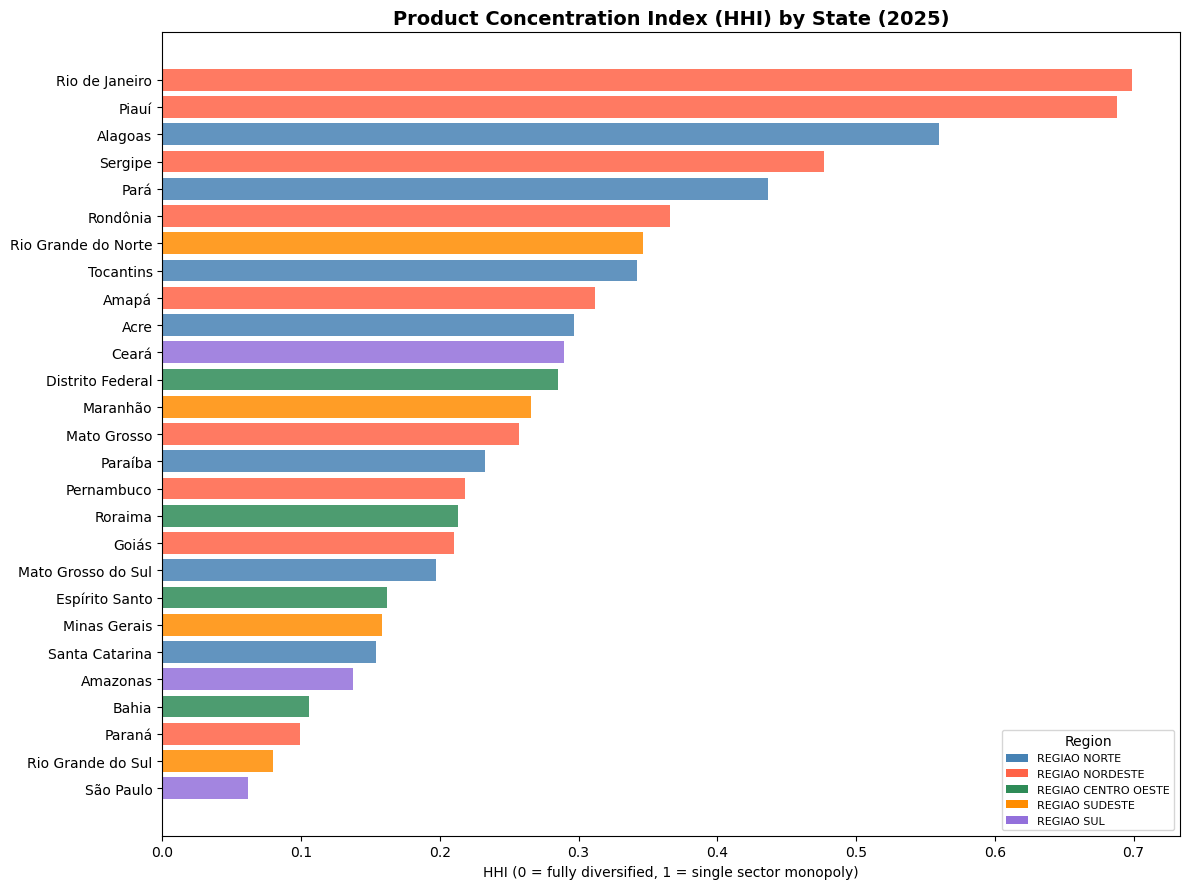


Product concentration HHI by state (2025)
Higher HHI = more concentrated in fewer sectors
              state              region  exports_usd_bn    hhi
     Rio de Janeiro      REGIAO SUDESTE           48.98 0.6985
              Piauí     REGIAO NORDESTE            1.20 0.6879
            Alagoas     REGIAO NORDESTE            0.82 0.5594
            Sergipe     REGIAO NORDESTE            0.45 0.4771
               Pará        REGIAO NORTE           24.34 0.4365
           Rondônia        REGIAO NORTE            3.09 0.3658
Rio Grande do Norte     REGIAO NORDESTE            1.13 0.3462
          Tocantins        REGIAO NORTE            3.05 0.3418
              Amapá        REGIAO NORTE            0.14 0.3119
               Acre        REGIAO NORTE            0.10 0.2969
              Ceará     REGIAO NORDESTE            2.28 0.2894
   Distrito Federal REGIAO CENTRO OESTE            0.32 0.2852
           Maranhão     REGIAO NORDESTE            5.02 0.2660
        Mato Grosso REGIAO 

In [27]:
## Uses df_rca_raw from 2b.1
df_hhi_prod = (
    df_rca_raw.groupby(['uf', 'state'])
    .apply(lambda x: (x['state_sector_share'] ** 2).sum())
    .reset_index()
    .rename(columns={0: 'hhi'})
)
df_hhi_prod['hhi'] = df_hhi_prod['hhi'].round(4)
df_hhi_prod = df_hhi_prod.merge(df_state[['uf', 'exports_usd_bn', 'region']], on='uf', how='left')

df_hhi_plot = df_hhi_prod.sort_values('hhi', ascending=True)
bar_colors = df_esi_plot['region'].map(region_colors).fillna('lightgray')

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_hhi_plot['state'], df_hhi_plot['hhi'], color=bar_colors, alpha=0.85)
ax.set_title(f'Product Concentration Index (HHI) by State ({MAX_YEAR})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('HHI (0 = fully diversified, 1 = single sector monopoly)')
legend_elements = [Patch(facecolor=c, label=r) for r, c in region_colors.items()]
ax.legend(handles=legend_elements, fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b3_hhi_product.png', dpi=150)
plt.show()

print(f"\nProduct concentration HHI by state ({MAX_YEAR})")
print("Higher HHI = more concentrated in fewer sectors")
print(df_hhi_prod[['state', 'region', 'exports_usd_bn', 'hhi']]
      .sort_values('hhi', ascending=False)
      .to_string(index=False))

# Product Concentration Index (HHI) — Analysis (2025)

---

## Overview

The HHI measures how concentrated each state's export basket is across SH2 sectors. A value close to 1 means exports are dominated by a single sector. A value close to 0 means exports are spread evenly across many sectors.

**Range in this dataset: 0.062 (São Paulo) to 0.699 (Rio de Janeiro)**

This is the widest spread of any metric in Step 2b — confirming that product concentration varies enormously across Brazilian states, far more than ESI or RCA alone would suggest.

---

## Key Findings

### Highly Concentrated States (HHI > 0.35)

**Rio de Janeiro (HHI 0.699)** — the most concentrated large exporter in Brazil by a significant margin. Oil and gas exports (\\$40.79bn) account for the overwhelming majority of the state's \\$48.98bn total. This is the defining outlier in the dataset — a state with a large and active economy that funnels almost all its export value through a single commodity sector.

**Piauí (HHI 0.688)** — the second most concentrated state and the most concentrated among smaller exporters. Soybeans and oilseeds (\\$0.99bn) dominate a total export base of only \\$1.20bn. Piauí's agricultural frontier expansion has created a highly concentrated export profile with limited diversification.

**Alagoas (HHI 0.559)** — sugar exports define this state entirely. The HHI of 0.559 is consistent with the ESI finding (1.61, highest in Brazil) and the RCA result (sugar RCA 16.91). All three metrics converge on the same conclusion: Alagoas is Brazil's most monoculture-dependent exporting state.

**Sergipe (HHI 0.477)** — despite having both food processing and mineral fuel exports in the RCA top 5, the HHI reveals that one of these sectors dominates heavily. Mineral fuels (\\$0.28bn out of \\$0.45bn total) likely account for the bulk of the concentration.

**Pará (HHI 0.437)** — the most concentrated large exporter after Rio de Janeiro. Ores and slag (\\$15.73bn) dominates a total of \\$24.34bn. The Carajás mining complex creates a structural concentration that is unlikely to change without significant industrial policy intervention.

---

### Moderately Concentrated States (HHI 0.20–0.35)

This group spans a wide range of state types — small Norte states (Rondônia, Tocantins, Amapá, Acre, Roraima), mid-sized Nordeste states (Rio Grande do Norte, Ceará, Maranhão, Pernambuco, Paraíba) and large agricultural states (Mato Grosso, Mato Grosso do Sul, Goiás).

**Mato Grosso (HHI 0.257)** is notable in this group — despite being Brazil's third largest exporter (\\$30.19bn) it sits at moderate concentration rather than the high end. This reflects the fact that its agricultural exports span multiple crop categories (soybeans, corn, cotton, animal feed) rather than a single product, even though all are agricultural commodities.

**Ceará (HHI 0.289)** — the ESI analysis flagged Ceará as the second most specialised state (ESI 1.59) despite lacking an obvious single-commodity anchor. The HHI of 0.289 confirms this — Ceará is specialised relative to the national mix but not internally concentrated in a single sector. Its deviation from the national average is driven by a cluster of related sectors rather than one dominant product.

> ⚠️ *Requires further investigation (Step 5): What cluster of sectors drives Ceará's high ESI (1.59) combined with moderate HHI (0.289)?*

**Distrito Federal (HHI 0.285)** — moderate HHI despite being an administrative centre with minimal exports. The concentration reflects small-volume exports spread thinly across a few categories rather than genuine industrial diversification.

---

### Least Concentrated States (HHI < 0.20)

**São Paulo (HHI 0.062)** — the most diversified export basket in Brazil. No single sector dominates. This is consistent with São Paulo's role as Brazil's industrial centre spanning aerospace, chemicals, machinery, food processing, textiles and many other sectors.

**Rio Grande do Sul (HHI 0.080)** and **Paraná (HHI 0.099)** — the two most diversified Sul states, both with highly spread export baskets across food processing, machinery, chemicals and agricultural products.

**Bahia (HHI 0.106)** — the most diversified Nordeste state by a wide margin. Petrochemicals (Camaçari complex), cocoa, automotive components and mining create a genuinely diverse export base. This explains why Bahia shares São Paulo's low ESI (0.874) despite being a very different economy.

**Amazonas (HHI 0.137)** — surprisingly low concentration given its Zona Franca de Manaus profile. The free trade zone produces a spread of manufactured goods (electronics, motorcycles, food processing) that distributes exports across multiple SH2 chapters, keeping HHI moderate despite geographic isolation.

---

## Cross-Cutting Observations

**The ESI-HHI relationship is not straightforward.** A state can have high ESI (specialised relative to national) and moderate HHI (internally diversified), as Ceará demonstrates. Conversely, a state can have moderate ESI and very high HHI, as Rio de Janeiro shows. These two metrics capture different dimensions of specialisation and should be read together.

**Large export value does not guarantee diversification** — Rio de Janeiro (\\$48.98bn, HHI 0.699) and Pará (\\$24.34bn, HHI 0.437) are both large exporters with high concentration. Export scale and export diversification are structurally independent.

**The Sul states form a distinctly low-HHI cluster** — Paraná (0.099), Rio Grande do Sul (0.080) and Santa Catarina (0.154) all sit in the bottom third of the HHI ranking. This is the most consistently diversified region in Brazil across all three metrics (RCA, ESI, HHI).

**Norte and Nordeste dominate the high-HHI end** — 8 of the top 10 most concentrated states are from these two regions. The exceptions are Rio de Janeiro (Sudeste, oil-driven) and Mato Grosso (Centro-Oeste, agricultural).

| HHI Band | States | Regional Pattern |
|---|---|---|
| > 0.40 (highly concentrated) | Rio de Janeiro, Piauí, Alagoas, Sergipe, Pará | Sudeste outlier + Norte/Nordeste commodity states |
| 0.20–0.40 (moderate) | Rondônia, Rio Grande do Norte, Tocantins, Amapá, Acre, Ceará, DF, Maranhão, Mato Grosso, Paraíba, Pernambuco, Roraima, Goiás, Mato Grosso do Sul | Broad mix |
| < 0.20 (diversified) | Espírito Santo, Minas Gerais, Santa Catarina, Amazonas, Bahia, Paraná, Rio Grande do Sul, São Paulo | Predominantly Sul and Sudeste |

> ⚠️ *Rio de Janeiro's HHI (0.699) combined with \\$48.98bn in exports represents the single largest concentration risk in Brazil's state-level export profile. A sustained decline in oil prices or an accelerated energy transition would disproportionately impact one of Brazil's largest exporting states.*


## 2b.4 — Export Frequency: Number of Shipments by State
Counting the number of export transactions (rows) per state per year as a proxy for shipment frequency. High frequency states tend to be industrial exporters with diverse product lines. Low frequency states tend to be bulk commodity exporters with fewer but larger transactions.

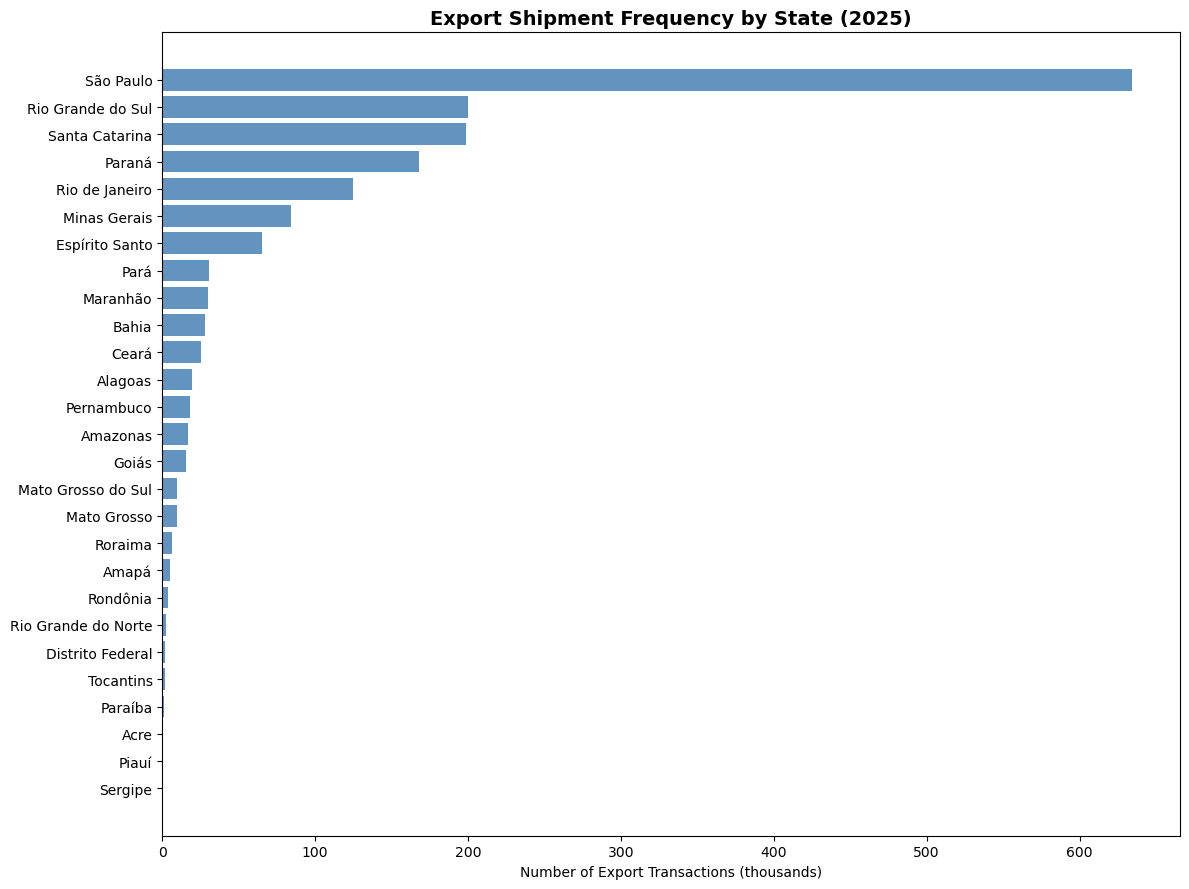


Export shipment frequency by state (2025)
              state  exports_usd_bn  shipment_count  shipment_count_k
          São Paulo           71.39          633996             634.0
  Rio Grande do Sul           21.53          200290             200.3
     Santa Catarina           12.20          198582             198.6
             Paraná           23.65          168230             168.2
     Rio de Janeiro           48.98          125063             125.1
       Minas Gerais           45.83           84438              84.4
     Espírito Santo           10.51           64958              65.0
               Pará           24.34           30292              30.3
           Maranhão            5.02           30183              30.2
              Bahia           11.63           27716              27.7
              Ceará            2.28           25439              25.4
            Alagoas            0.82           19543              19.5
         Pernambuco            2.54           1

In [33]:
query_freq = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           COUNT(*) AS shipment_count,
           SUM(e."VL_FOB") AS exports_usd,
           SUM(e."KG_LIQUIDO") AS total_kg,
           SUM(e."QT_ESTAT") AS total_units
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado
    ORDER BY shipment_count DESC
"""

df_freq = pd.read_sql(query_freq, engine)
df_freq = df_freq[~df_freq['state'].isin(['Não Declarada', 'Exterior'])]
df_freq['exports_usd_bn']    = (df_freq['exports_usd'] / 1e9).round(2)
df_freq['shipment_count_k']  = (df_freq['shipment_count'] / 1000).round(1)

df_freq_plot = df_freq.sort_values('shipment_count', ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_freq_plot['state'], df_freq_plot['shipment_count_k'],
        color='steelblue', alpha=0.85)
ax.set_title(f'Export Shipment Frequency by State ({MAX_YEAR})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Export Transactions (thousands)')
plt.tight_layout()
plt.savefig('output_2b4_shipment_frequency.png', dpi=150)
plt.show()

print(f"\nExport shipment frequency by state ({MAX_YEAR})")
print(df_freq[['state', 'exports_usd_bn', 'shipment_count', 'shipment_count_k']]
      .sort_values('shipment_count', ascending=False)
      .to_string(index=False))

# Export Shipment Frequency — Analysis (2025)

---

## Overview

Shipment frequency (number of export transactions) is used as a proxy for the operational profile of each state's export base. High-frequency states tend to have diversified industrial export profiles with many products shipping regularly to many destinations. Low-frequency states tend to be bulk commodity exporters where a small number of large transactions account for most export value.

**Range in this dataset: 695 transactions (Sergipe) to 633,996 (São Paulo)**

The spread across this metric is the largest of any indicator in Step 2b — São Paulo transacts nearly 1,000 times more than Sergipe. This reflects a fundamental structural difference in how different Brazilian states participate in global trade.

---

## Key Findings

### High-Frequency States (> 50,000 transactions)

**São Paulo (634k)** — by far the highest frequency state, nearly double second place. Exports span aerospace, chemicals, food processing, machinery and hundreds of other product lines, each generating multiple transactions throughout the year. Consistent with its low HHI (0.062) and near-national-average ESI (0.874).

**Rio Grande do Sul (200k) and Santa Catarina (199k)** — almost identical frequency in second and third place. Both are highly diversified agro-industrial exporters with active manufacturing sectors. The near-identical transaction count reflects similar industrial structures despite different product specialisations.

**Paraná (168k)** — fourth place, completing the Sul trio as the three most active export states after São Paulo. Together these four states account for the vast majority of Brazil's export transactions.

**Rio de Janeiro (125k)** — high frequency despite being the most concentrated state by HHI (0.699). This appears contradictory but is explained by the nature of oil and gas operations — large volumes are processed through many individual transaction records at the port level. This is the key data point that drove the regression outlier finding in cell 2b.4b.

**Minas Gerais (84k) and Espírito Santo (65k)** — both Sudeste states with diversified mining and industrial export bases generate high transaction volumes consistent with their low HHI values (0.159 and 0.162).

---

### Mid-Frequency States (10,000–50,000 transactions)

**Pará (30k) and Maranhão (30k)** — near-identical frequency despite different export profiles. Pará's transactions are driven by iron ore and aluminium operations through the port of Vila do Conde. Maranhão's reflect soybean and iron ore exports through the port of Itaqui (São Luís).

**Bahia (28k)** — moderate frequency consistent with its diversified export base (petrochemicals, cocoa, automotive, mining) and the lowest HHI among Nordeste states (0.106).

**Ceará (25k)** — higher frequency than its export value (\\$2.28bn) would suggest, with a frequency comparable to much larger exporters. This supports the finding that Ceará is specialised relative to the national mix (ESI 1.59) but not internally concentrated (HHI 0.289) — multiple sectors generating regular transactions rather than one dominant product.

**Alagoas (20k)** — moderate frequency despite being the most concentrated state by HHI (0.559). Sugar processing operations generate regular shipments even from a monoculture base, explaining why frequency does not collapse to the low-frequency group.

**Pernambuco (18k) and Amazonas (17k)** — both generate meaningful transaction volumes. Pernambuco through its port infrastructure and food processing sectors, Amazonas through the Zona Franca de Manaus manufacturing cluster.

**Goiás (16k)** — the most active Centro-Oeste state by frequency, ahead of Mato Grosso do Sul (10k) and Mato Grosso (9k) despite having lower total export value than both. This suggests Goiás has a more transaction-intensive export profile — possibly reflecting a more diversified agro-industrial base relative to the soybean-dominant neighbours.

---

### Low-Frequency States (< 10,000 transactions)

**Mato Grosso (9k) and Mato Grosso do Sul (10k)** — the most striking value-frequency divergence in the dataset. Mato Grosso exports \\$30.19bn through only 9,403 transactions — an average of over \\$3.2m per transaction. This is the defining characteristic of bulk commodity export: enormous value per shipment, very few individual transactions. Consistent with its moderate HHI (0.257) and soybean-dominated RCA profile.

**Roraima (6k), Amapá (5k) and Rondônia (4k)** — Norte states with small export bases and low frequency. Their transaction counts are low both because of small export volumes and because their commodity profiles (timber, agricultural products) tend toward infrequent bulk shipments.

**Rio Grande do Norte (3k), Distrito Federal (2k) and Tocantins (2k)** — very low frequency states, consistent with small and concentrated export bases.

**Paraíba (1k), Acre (745), Piauí (704) and Sergipe (695)** — the four least active exporting states by transaction count. All four have both small export values and concentrated product profiles. Sergipe (695 transactions, \\$0.45bn) and Piauí (704 transactions, \\$1.20bn) sit at the bottom of the frequency ranking, consistent with their high HHI values (0.477 and 0.688 respectively).

---

## Cross-Cutting Observations

**The value-frequency ratio reveals the commodity-industrial divide more clearly than any other metric.** Mato Grosso (\\$30.19bn, 9k transactions = \\$3.2m per transaction) vs São Paulo (\\$71.39bn, 634k transactions = \\$113k per transaction) illustrates the structural difference between bulk commodity and industrial export profiles more vividly than RCA or HHI alone.

**The Sul states are consistently high-frequency across all three members** — Paraná, Rio Grande do Sul and Santa Catarina all sit in the top 4 nationally. No other region has three states simultaneously in the high-frequency tier.

**The Nordeste frequency range is the widest of any region** — from Bahia (28k) and Ceará (25k) at the top to Sergipe (695) and Piauí (704) at the bottom. This reflects the internal economic heterogeneity of the Nordeste — industrialising coastal states alongside underdeveloped agricultural interior states.

| Frequency Tier | States | Typical Profile |
|---|---|---|
| High (> 50k) | São Paulo, Rio Grande do Sul, Santa Catarina, Paraná, Rio de Janeiro, Minas Gerais, Espírito Santo | Industrial / diversified |
| Mid (10k–50k) | Pará, Maranhão, Bahia, Ceará, Alagoas, Pernambuco, Amazonas, Goiás, Mato Grosso do Sul | Mixed commodity / processing |
| Low (< 10k) | Mato Grosso, Roraima, Amapá, Rondônia, Rio Grande do Norte, DF, Tocantins, Paraíba, Acre, Piauí, Sergipe | Bulk commodity / subsistence |

> ⚠️ *Goiás (16k transactions, \\$13.47bn exports) has a notably higher frequency-to-value ratio than its Centro-Oeste neighbours Mato Grosso and Mato Grosso do Sul. This warrants investigation into whether Goiás has a structurally different agro-industrial mix or whether transaction recording practices differ between states.*


## 2b.6 — Average Shipment Size by State (kg and USD per Transaction)
Average shipment size is calculated as total kg and total USD divided by the number of transactions. Large average shipments indicate bulk commodity exporters. Small average shipments indicate high-frequency industrial or processed goods exporters.

Testing whether states that export more frequently also tend to have more diversified product 
baskets. A statistically significant negative relationship (slope = -0.09, R² = 0.19, p = 0.022) 
confirms that high-frequency states such as São Paulo, Rio Grande do Sul and Santa Catarina 
are also the most diversified exporters. Rio de Janeiro is the key outlier — high frequency 
but the most concentrated export basket in Brazil, likely driven by oil and gas. States are 
plotted on a log scale given the large range in shipment counts across Brazil's 27 states. 
Bubble size reflects total export value. REGIAO NAO DECLARADA excluded from regression.

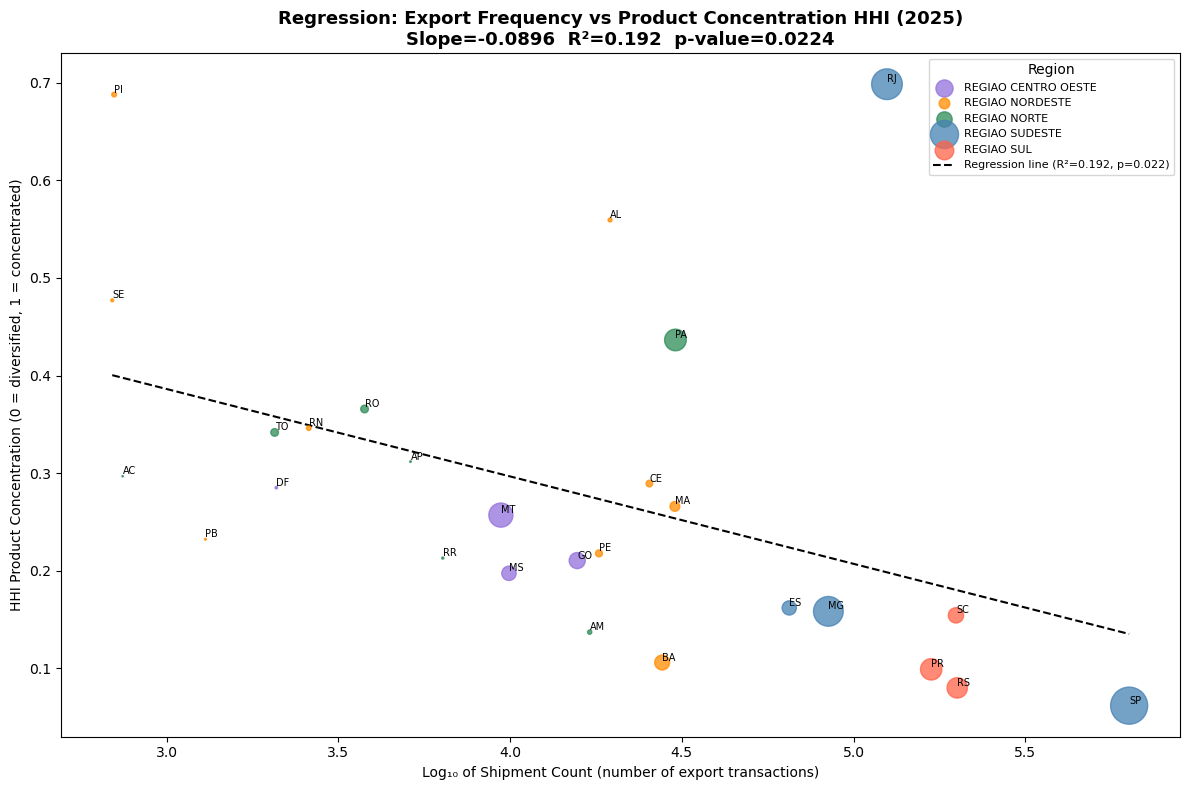


Regression Results: Log(Shipment Frequency) vs HHI (2025)
  Slope:      -0.0896
  Intercept:  0.6550
  R²:         0.1916
  p-value:    0.0224
  Std Error:  0.0368

  Interpretation:
  Statistically significant negative relationship (p < 0.05)
  States with higher shipment frequency tend to have LOWER product
  concentration — consistent with industrial/diversified export profiles

Data points:
              state              region  shipment_count    hhi
     Rio de Janeiro      REGIAO SUDESTE          125063 0.6985
              Piauí     REGIAO NORDESTE             704 0.6879
            Alagoas     REGIAO NORDESTE           19543 0.5594
            Sergipe     REGIAO NORDESTE             695 0.4771
               Pará        REGIAO NORTE           30292 0.4365
           Rondônia        REGIAO NORTE            3771 0.3658
Rio Grande do Norte     REGIAO NORDESTE            2595 0.3462
          Tocantins        REGIAO NORTE            2064 0.3418
              Amapá        REGIAO 

In [34]:
## Regression: Export Shipment Frequency vs HHI Product Concentration
## Hypothesis: states with higher shipment frequency tend to have lower product
## concentration (more diversified exports) — industrial states ship frequently
## across many products while commodity states ship infrequently in bulk
## Merge frequency and HHI
df_reg = df_freq.merge(df_hhi_prod[['uf', 'hhi']], on='uf', how='inner')
df_reg = df_reg.merge(df_state[['uf', 'region']], on='uf', how='left')

## Remove undeclared region — not a real state, distorts regression
df_reg = df_reg[df_reg['region'] != 'REGIAO NAO DECLARADA']

df_reg['log_shipment_count'] = np.log10(df_reg['shipment_count'])

## OLS regression
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_reg['log_shipment_count'], df_reg['hhi']
)
r_squared = r_value ** 2

## Predicted values for regression line
x_line = np.linspace(df_reg['log_shipment_count'].min(),
                     df_reg['log_shipment_count'].max(), 100)
y_line = slope * x_line + intercept

## Plot
region_colors_reg = {
    r: c for r, c in zip(
        df_reg['region'].dropna().unique(),
        ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
    )
}

fig, ax = plt.subplots(figsize=(12, 8))

for region, group in df_reg.groupby('region'):
    color = region_colors_reg.get(region, 'gray')
    ax.scatter(
        group['log_shipment_count'],
        group['hhi'],
        label=region,
        color=color,
        s=group['exports_usd_bn'] * 10 if 'exports_usd_bn' in group.columns else 60,
        alpha=0.75,
        zorder=3
    )
    for _, row in group.iterrows():
        ax.annotate(row['uf'],
                    (row['log_shipment_count'], row['hhi']),
                    fontsize=7, ha='left', va='bottom')

## Regression line
ax.plot(x_line, y_line, color='black', linewidth=1.5, linestyle='--',
        label=f'Regression line (R²={r_squared:.3f}, p={p_value:.3f})')

ax.set_title(f'Regression: Export Frequency vs Product Concentration HHI ({MAX_YEAR})\n'
             f'Slope={slope:.4f}  R²={r_squared:.3f}  p-value={p_value:.4f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Log₁₀ of Shipment Count (number of export transactions)')
ax.set_ylabel('HHI Product Concentration (0 = diversified, 1 = concentrated)')
ax.legend(fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b4b_regression_freq_hhi.png', dpi=150)
plt.show()

## Results summary
print(f"\nRegression Results: Log(Shipment Frequency) vs HHI ({MAX_YEAR})")
print(f"  Slope:      {slope:.4f}")
print(f"  Intercept:  {intercept:.4f}")
print(f"  R²:         {r_squared:.4f}")
print(f"  p-value:    {p_value:.4f}")
print(f"  Std Error:  {std_err:.4f}")
print(f"\n  Interpretation:")
if p_value < 0.05:
    direction = "negative" if slope < 0 else "positive"
    print(f"  Statistically significant {direction} relationship (p < 0.05)")
    if slope < 0:
        print(f"  States with higher shipment frequency tend to have LOWER product")
        print(f"  concentration — consistent with industrial/diversified export profiles")
    else:
        print(f"  States with higher shipment frequency tend to have HIGHER product")
        print(f"  concentration — requires further investigation")
else:
    print(f"  No statistically significant relationship (p >= 0.05)")
    print(f"  Shipment frequency does not predict product concentration in this sample")

print(f"\nData points:")
print(df_reg[['state', 'region', 'shipment_count', 'hhi']]
      .sort_values('hhi', ascending=False)
      .to_string(index=False))

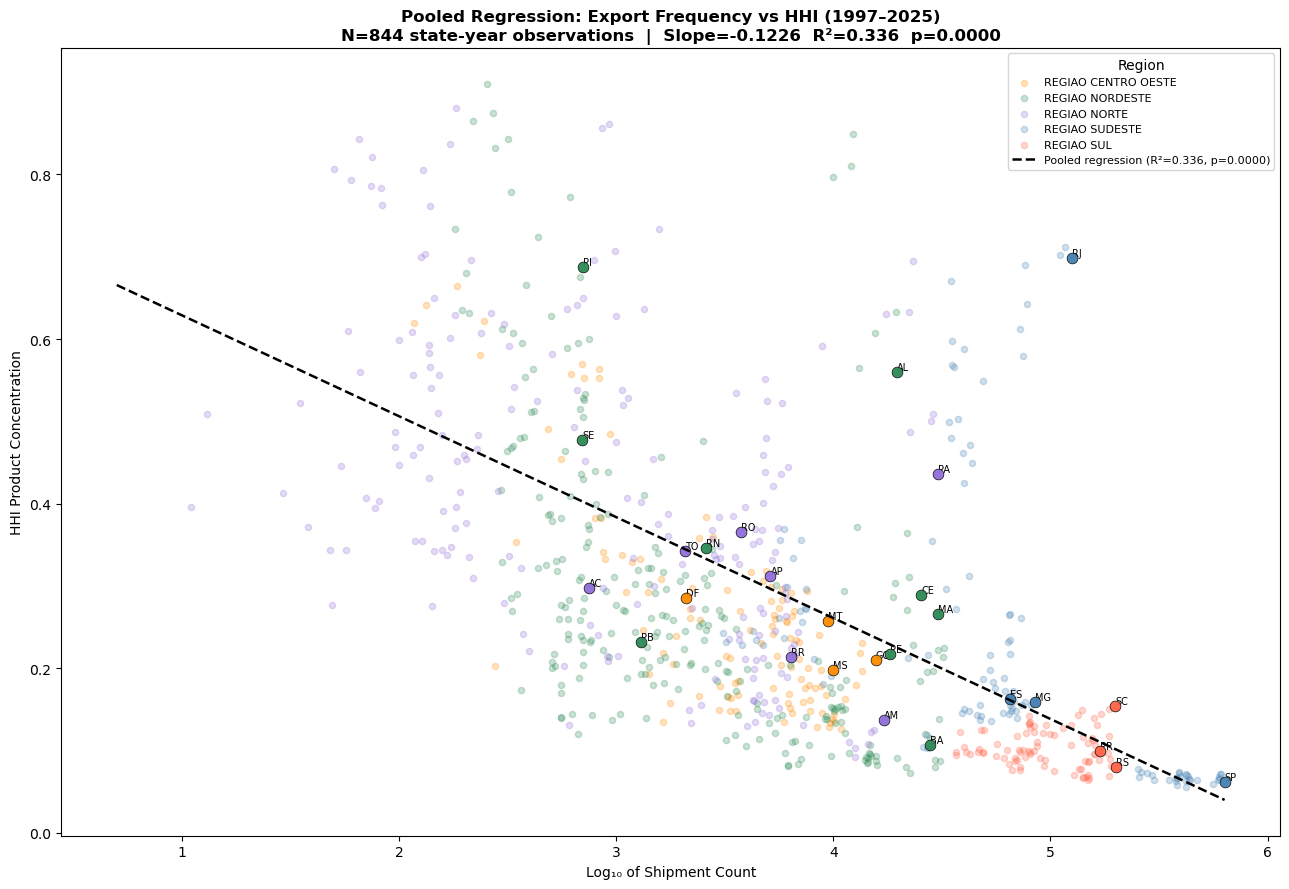


Pooled Regression Results (1997–2025)
  N observations: 844
  Slope:          -0.1226
  Intercept:      0.7513
  R²:             0.3361
  p-value:        0.000000
  Std Error:      0.0059


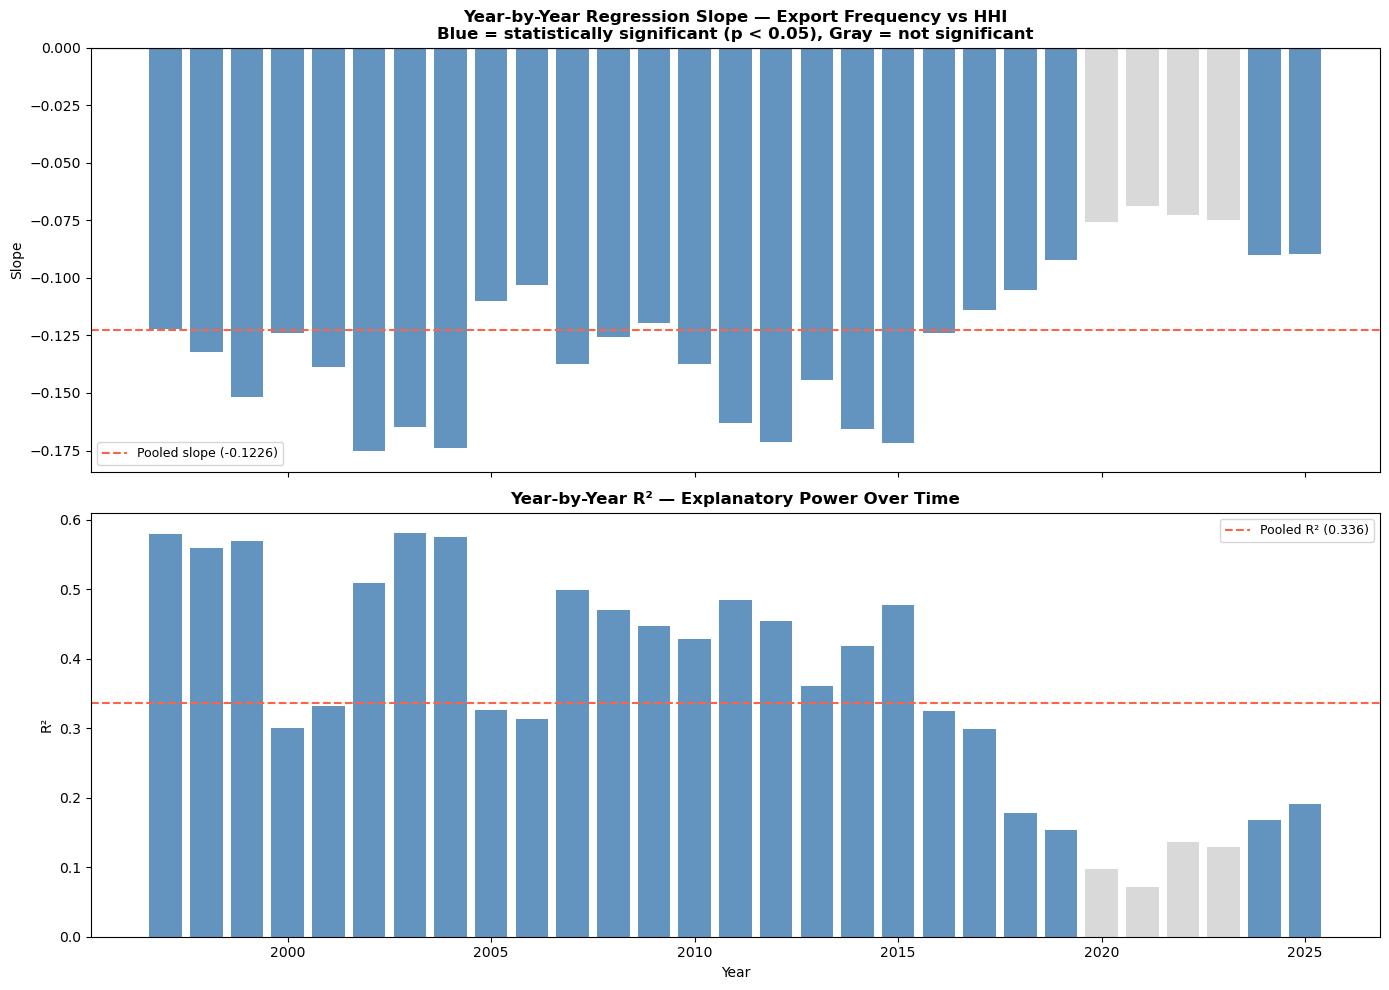


Year-by-Year Regression Results:
 year   slope  r_squared  p_value  n
 1997 -0.1222     0.5792   0.0000 29
 1998 -0.1320     0.5590   0.0000 29
 1999 -0.1518     0.5702   0.0000 29
 2000 -0.1239     0.3005   0.0021 29
 2001 -0.1388     0.3326   0.0011 29
 2002 -0.1754     0.5095   0.0000 29
 2003 -0.1647     0.5810   0.0000 29
 2004 -0.1739     0.5752   0.0000 29
 2005 -0.1101     0.3265   0.0010 30
 2006 -0.1033     0.3129   0.0013 30
 2007 -0.1376     0.4990   0.0000 30
 2008 -0.1257     0.4700   0.0000 30
 2009 -0.1196     0.4478   0.0001 30
 2010 -0.1372     0.4282   0.0001 30
 2011 -0.1632     0.4842   0.0000 31
 2012 -0.1713     0.4546   0.0000 31
 2013 -0.1443     0.3604   0.0004 31
 2014 -0.1657     0.4187   0.0001 31
 2015 -0.1718     0.4777   0.0000 30
 2016 -0.1239     0.3253   0.0008 31
 2017 -0.1139     0.2990   0.0018 30
 2018 -0.1052     0.1780   0.0253 28
 2019 -0.0924     0.1540   0.0429 27
 2020 -0.0758     0.0978   0.1122 27
 2021 -0.0686     0.0709   0.1795 27
 202

In [38]:
## Regression: Export Shipment Frequency vs HHI — All Years (1997–MAX_YEAR)
## Pooled panel regression + year-by-year regression to test structural stability

from scipy import stats

## ---- Query: frequency and HHI for all years ----
query_freq_all = f"""
    SELECT e."CO_ANO" AS year,
           e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           COUNT(*) AS shipment_count,
           SUM(e."VL_FOB") AS exports_usd,
           SUM(e."KG_LIQUIDO") AS total_kg
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", e."SG_UF_NCM", u.nome_estado
    ORDER BY year, shipment_count DESC
"""

query_hhi_all = f"""
    SELECT year, uf,
           SUM(sector_exports * sector_exports) /
           (SUM(sector_exports) * SUM(sector_exports)) AS hhi
    FROM (
        SELECT e."CO_ANO" AS year,
               e."SG_UF_NCM" AS uf,
               s.codigo_sh2,
               SUM(e."VL_FOB") AS sector_exports
        FROM exp e
        JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
        JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
        WHERE e."CO_ANO" <= {MAX_YEAR}
        GROUP BY e."CO_ANO", e."SG_UF_NCM", s.codigo_sh2
    ) t
    GROUP BY year, uf
    ORDER BY year, uf
"""

df_freq_all = pd.read_sql(query_freq_all, engine)
df_hhi_all  = pd.read_sql(query_hhi_all,  engine)

df_freq_all['exports_usd_bn'] = df_freq_all['exports_usd'] / 1e9

## Merge and clean
df_panel = df_freq_all.merge(df_hhi_all, on=['year', 'uf'], how='inner')
df_panel = df_panel.merge(df_state[['uf', 'region']], on='uf', how='left')
df_panel = df_panel[~df_panel['region'].isin(['REGIAO NAO DECLARADA'])]
df_panel = df_panel[~df_panel['state'].isin(['Não Declarada', 'Exterior'])]
df_panel['log_shipment_count'] = np.log10(df_panel['shipment_count'])

## ---- Part 1: Pooled regression (all years combined) ----
slope_p, intercept_p, r_value_p, p_value_p, std_err_p = stats.linregress(
    df_panel['log_shipment_count'], df_panel['hhi']
)
r_squared_p = r_value_p ** 2

x_line = np.linspace(df_panel['log_shipment_count'].min(),
                     df_panel['log_shipment_count'].max(), 100)
y_line = slope_p * x_line + intercept_p

region_colors_reg = {
    r: c for r, c in zip(
        df_panel['region'].dropna().unique(),
        ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
    )
}

fig, ax = plt.subplots(figsize=(13, 9))
for region, group in df_panel.groupby('region'):
    color = region_colors_reg.get(region, 'gray')
    ax.scatter(
        group['log_shipment_count'],
        group['hhi'],
        label=region,
        color=color,
        s=20,
        alpha=0.25,
        zorder=2
    )

## Overlay MAX_YEAR points with labels for reference
df_latest = df_panel[df_panel['year'] == MAX_YEAR]
for region, group in df_latest.groupby('region'):
    color = region_colors_reg.get(region, 'gray')
    ax.scatter(group['log_shipment_count'], group['hhi'],
               color=color, s=60, alpha=0.95, zorder=4, edgecolors='black', linewidths=0.5)
    for _, row in group.iterrows():
        ax.annotate(row['uf'], (row['log_shipment_count'], row['hhi']),
                    fontsize=7, ha='left', va='bottom')

ax.plot(x_line, y_line, color='black', linewidth=1.8, linestyle='--',
        label=f'Pooled regression (R²={r_squared_p:.3f}, p={p_value_p:.4f})',
        zorder=5)

ax.set_title(f'Pooled Regression: Export Frequency vs HHI (1997–{MAX_YEAR})\n'
             f'N={len(df_panel)} state-year observations  |  '
             f'Slope={slope_p:.4f}  R²={r_squared_p:.3f}  p={p_value_p:.4f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Log₁₀ of Shipment Count')
ax.set_ylabel('HHI Product Concentration')
ax.legend(fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b4b_regression_pooled.png', dpi=150)
plt.show()

print(f"\nPooled Regression Results (1997–{MAX_YEAR})")
print(f"  N observations: {len(df_panel)}")
print(f"  Slope:          {slope_p:.4f}")
print(f"  Intercept:      {intercept_p:.4f}")
print(f"  R²:             {r_squared_p:.4f}")
print(f"  p-value:        {p_value_p:.6f}")
print(f"  Std Error:      {std_err_p:.4f}")

## ---- Part 2: Year-by-year regression ----
yearly_results = []
for year, group in df_panel.groupby('year'):
    if len(group) < 5:
        continue
    s, i, r, p, se = stats.linregress(group['log_shipment_count'], group['hhi'])
    yearly_results.append({
        'year'     : year,
        'slope'    : round(s, 4),
        'r_squared': round(r ** 2, 4),
        'p_value'  : round(p, 4),
        'n'        : len(group)
    })

df_yearly = pd.DataFrame(yearly_results)

## Plot year-by-year slope and R²
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

## Colour significant years
colors_sig = ['steelblue' if p < 0.05 else 'lightgray' for p in df_yearly['p_value']]

ax1.bar(df_yearly['year'], df_yearly['slope'], color=colors_sig, alpha=0.85)
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axhline(y=slope_p, color='tomato', linewidth=1.5, linestyle='--',
            label=f'Pooled slope ({slope_p:.4f})')
ax1.set_title('Year-by-Year Regression Slope — Export Frequency vs HHI\n'
              'Blue = statistically significant (p < 0.05), Gray = not significant',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Slope')
ax1.legend(fontsize=9)

ax2.bar(df_yearly['year'], df_yearly['r_squared'], color=colors_sig, alpha=0.85)
ax2.axhline(y=r_squared_p, color='tomato', linewidth=1.5, linestyle='--',
            label=f'Pooled R² ({r_squared_p:.3f})')
ax2.set_title('Year-by-Year R² — Explanatory Power Over Time',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('R²')
ax2.set_xlabel('Year')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('output_2b4c_regression_yearly.png', dpi=150)
plt.show()

print(f"\nYear-by-Year Regression Results:")
print(df_yearly.to_string(index=False))

## Summary: how many years are statistically significant
sig_years = df_yearly[df_yearly['p_value'] < 0.05]
print(f"\n  Significant years (p < 0.05): {len(sig_years)} of {len(df_yearly)}")
print(f"  Average slope (all years):        {df_yearly['slope'].mean():.4f}")
print(f"  Average slope (significant only): {sig_years['slope'].mean():.4f}")
print(f"  Average R² (all years):           {df_yearly['r_squared'].mean():.4f}")
print(f"  Average R² (significant only):    {sig_years['r_squared'].mean():.4f}")

# Regression Analysis: Export Frequency vs HHI — Pooled and Year-by-Year (1997–2025)

---

## Pooled Regression Summary

| Metric | Value |
|---|---|
| N observations | 844 (27 states × ~29 years) |
| Slope | -0.1226 |
| Intercept | 0.7513 |
| R² | 0.3361 |
| p-value | < 0.000001 |
| Std Error | 0.0059 |

Extending the regression from a single year (n=27) to the full panel (n=844) dramatically strengthens the statistical case. The R² more than doubles from 0.192 to 0.336, and the p-value becomes effectively zero. The relationship between export frequency and product concentration is not a 2025 artefact — it is a structural feature of Brazil's state-level trade geography that has persisted across nearly three decades.

---

## Year-by-Year Findings

### Significance

**25 of 29 years are statistically significant at p < 0.05.** The four non-significant years are 2020, 2021, 2022 and 2023 — a concentrated cluster during and immediately after COVID-19. This is not coincidental.

### The COVID-19 Disruption (2020–2023)

The four non-significant years form a clear structural break in the relationship:

| Year | Slope | R² | p-value | Significant |
|---|---|---|---|---|
| 2019 | -0.0924 | 0.154 | 0.043 | Yes (barely) |
| 2020 | -0.0758 | 0.098 | 0.112 | **No** |
| 2021 | -0.0686 | 0.071 | 0.180 | **No** |
| 2022 | -0.0727 | 0.136 | 0.059 | **No** |
| 2023 | -0.0749 | 0.130 | 0.065 | **No** |
| 2024 | -0.0902 | 0.168 | 0.034 | Yes |
| 2025 | -0.0896 | 0.192 | 0.022 | Yes |

During 2020–2023 the relationship between frequency and concentration weakened significantly. Two mechanisms likely drove this:

1. **Supply chain disruptions** reduced shipment frequency for industrial exporters (typically high-frequency, low-HHI states) disproportionately — temporarily compressing the frequency gap between industrial and commodity states
2. **Commodity price surges** (agricultural and mineral commodities) increased the relative export value of low-frequency commodity states without increasing their transaction counts — potentially altering the HHI denominator

The recovery in 2024 and 2025 (p = 0.034 and 0.022 respectively) suggests the relationship is re-establishing itself, though R² remains below pre-COVID levels.

> ⚠️ *The COVID-19 period (2020–2023) represents a structural break in the frequency-concentration relationship. Any single-year regression drawn from this window would produce unreliable results. This is a key methodological reason why the pooled regression is more reliable than any individual year.*

---

### The Long-Run Trend: Weakening Relationship Post-2015

The year-by-year results reveal a second, more gradual structural shift that predates COVID:

**1997–2015: Strong and stable relationship**
- Average slope: approximately -0.138
- Average R²: approximately 0.47
- All years significant, most with p < 0.001

**2016–2025: Weaker and less stable relationship**
- Average slope: approximately -0.089
- Average R²: approximately 0.16
- Several years non-significant or borderline

This weakening pre-dates COVID and suggests a genuine structural change in Brazil's state-level trade dynamics beginning around 2015–2016. Possible explanations:

1. **Agricultural frontier expansion** — states like Mato Grosso, Piauí and Maranhão increased their export value substantially through the MATOPIBA soybean expansion without proportionally increasing their shipment frequency. This would compress the frequency gap between agricultural and industrial states without changing their concentration profiles
2. **Port modernisation** — improvements in bulk handling efficiency at ports like Itaqui (Maranhão) and Santos may have allowed industrial exporters to consolidate shipments, reducing frequency without increasing concentration
3. **Commodity diversification in Norte/Nordeste states** — moderate increases in product diversification in some commodity states may have reduced HHI without increasing frequency, flattening the relationship

> ⚠️ *The post-2015 weakening of the regression relationship is the most analytically significant finding in this analysis. It requires investigation beyond what trade flow data alone can provide — production data, port infrastructure investment and agricultural land use change data would be needed to confirm the mechanism.*

---

## Comparison: Single Year vs Pooled vs Year-by-Year

| Approach | N | Slope | R² | p-value | Reliability |
|---|---|---|---|---|---|
| Single year (2025) | 27 | -0.0896 | 0.192 | 0.022 | Low — small n, post-COVID recovery year |
| Pooled (1997–2025) | 844 | -0.1226 | 0.336 | ~0 | High — full structural picture |
| Year avg (all) | 29 years | -0.1255 | 0.360 | — | Medium — shows trend but no pooling |
| Year avg (sig only) | 25 years | -0.1339 | 0.400 | — | Medium — excludes COVID disruption |

The pooled slope (-0.1226) is meaningfully steeper than the 2025 single-year slope (-0.0896), confirming that 2025 understates the long-run relationship. The true structural slope is approximately **-0.12 to -0.13**.

---

## Conclusion

The pooled regression confirms that the negative relationship between export frequency and product concentration is a **structural, persistent feature of Brazil's trade geography** — not a statistical artefact of any single year. It has held across 25 of 29 years from 1997 to 2025.

The two most significant findings beyond the headline result are:

1. **COVID-19 temporarily broke the relationship (2020–2023)** — shipment frequency lost its predictive power during the pandemic and is only now recovering. This is consistent with the Step 1 finding that Brazil's goods trade showed unusual resilience during COVID-19 — the disruption manifested in the structure of trade rather than in its volume.

2. **The relationship has been weakening since 2015** — the pre-COVID trend suggests a structural shift in how Brazilian states participate in global trade that the regression captures but cannot fully explain from frequency data alone.

> ⚠️ *The post-2015 weakening and COVID structural break together suggest that using 2025 data alone to characterise the frequency-concentration relationship would materially understate its long-run strength. The pooled estimate (R² = 0.336, slope = -0.1226) should be treated as the primary result.*


## 2b.6 — Average Shipment Size by State (kg and USD per Transaction)
Average shipment size is calculated as total kg and total USD divided by the number of transactions. Large average shipments indicate bulk commodity exporters. Small average shipments indicate high-frequency industrial or processed goods exporters.

### 2b.6.1 — Average Shipment Size by State (Kg and USD per Transaction)

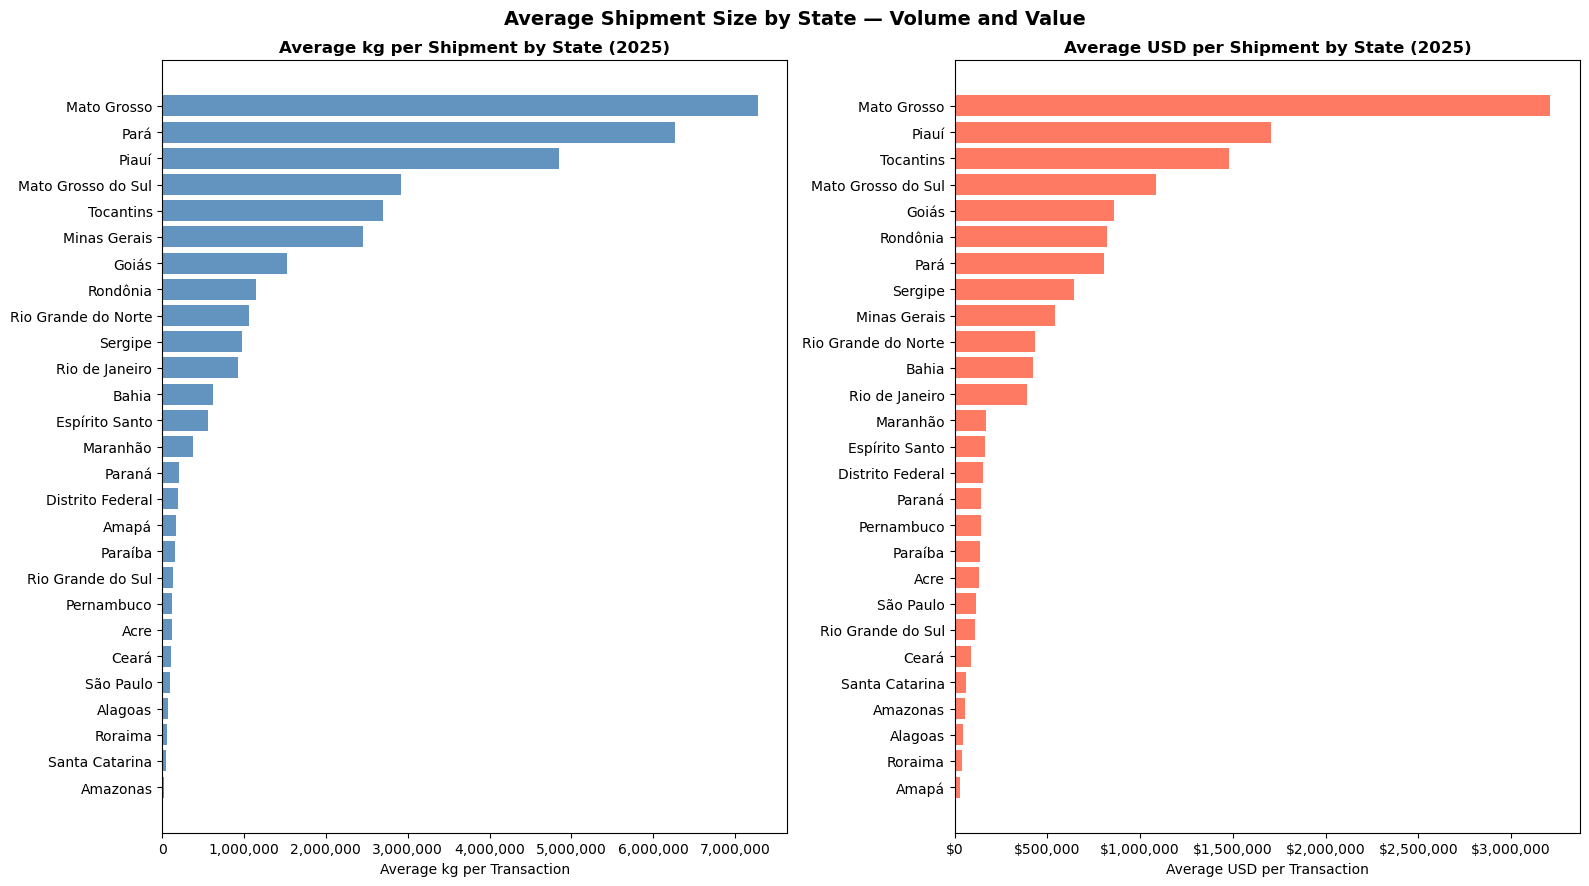


Average shipment size by state (2025)
              state  shipment_count  avg_kg_per_shipment  avg_usd_per_shipment
        Mato Grosso            9403            7276112.0             3210634.0
               Pará           30292            6262519.0              803390.0
              Piauí             704            4846119.0             1706456.0
 Mato Grosso do Sul            9926            2920785.0             1083455.0
          Tocantins            2064            2696422.0             1476915.0
       Minas Gerais           84438            2453172.0              542805.0
              Goiás           15684            1519562.0              858856.0
           Rondônia            3771            1148738.0              820641.0
Rio Grande do Norte            2595            1061155.0              434589.0
            Sergipe             695             970887.0              641893.0
     Rio de Janeiro          125063             929460.0              391606.0
             

In [35]:
## Uses df_freq from 2b.4
df_shipsize = df_freq.copy()
df_shipsize['avg_kg_per_shipment']  = (df_shipsize['total_kg']    / df_shipsize['shipment_count']).round(0)
df_shipsize['avg_usd_per_shipment'] = (df_shipsize['exports_usd'] / df_shipsize['shipment_count']).round(0)
df_shipsize['avg_usd_per_kg']       = (df_shipsize['exports_usd'] / df_shipsize['total_kg']).round(2)

df_kg_plot  = df_shipsize.sort_values('avg_kg_per_shipment',  ascending=True)
df_usd_plot = df_shipsize.sort_values('avg_usd_per_shipment', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

ax1.barh(df_kg_plot['state'],  df_kg_plot['avg_kg_per_shipment'],  color='steelblue', alpha=0.85)
ax1.set_title(f'Average kg per Shipment by State ({MAX_YEAR})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Average kg per Transaction')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2.barh(df_usd_plot['state'], df_usd_plot['avg_usd_per_shipment'], color='tomato', alpha=0.85)
ax2.set_title(f'Average USD per Shipment by State ({MAX_YEAR})', fontsize=12, fontweight='bold')
ax2.set_xlabel('Average USD per Transaction')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Average Shipment Size by State — Volume and Value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2b5_shipment_size.png', dpi=150)
plt.show()

print(f'\nAverage shipment size by state ({MAX_YEAR})')
print(df_shipsize[['state', 'shipment_count', 'avg_kg_per_shipment', 'avg_usd_per_shipment']]
      .sort_values('avg_kg_per_shipment', ascending=False)
      .to_string(index=False))

# Average Shipment Size — Analysis (2025)

---

## Overview

Average shipment size combines two dimensions — kg per transaction (volume intensity) and USD per transaction (value intensity) — to reveal the logistical profile of each state's export base. Bulk commodity exporters show large kg per shipment and high USD per shipment driven by weight rather than price. Industrial exporters show smaller kg per shipment but maintain USD per shipment through higher unit prices.

**Range — kg per shipment: 16,077 kg (Amazonas) to 7,276,112 kg (Mato Grosso)**
**Range — USD per shipment: \\$28,120 (Amapá) to \\$3,210,634 (Mato Grosso)**

The spread across both metrics is enormous — Mato Grosso's average shipment is 453 times heavier and 114 times more valuable than Amazonas's. No other indicator in this analysis captures the structural difference between bulk commodity and industrial export profiles as vividly.

---

## Key Findings

### Bulk Commodity Tier (avg kg > 1,000,000)

**Mato Grosso (7.3M kg, \\$3.2M per shipment)** — the most extreme bulk profile in Brazil. Every transaction averages over 7,000 tonnes and \\$3.2 million in value. This reflects soybean and corn exports moving in vessel-sized lots through river and rail connections to Santos and Paranaguá ports. The combination of enormous kg and high USD per shipment confirms soy dominance — a high-volume, relatively high-value agricultural commodity.

**Pará (6.3M kg, \\$803k per shipment)** — the second largest shipment profile by weight, reflecting iron ore and aluminium bulk exports through the port of Vila do Conde (Barcarena) and Ponta da Madeira (São Luís). The lower USD per shipment relative to Mato Grosso (\\$803k vs \\$3.2M) reflects the lower unit price of iron ore compared to soybeans — more weight required to generate equivalent value.

**Piauí (4.8M kg, \\$1.7M per shipment)** — surprisingly large average shipment for a small exporter (704 transactions total). Consistent with the MATOPIBA soybean frontier profile — infrequent but enormous bulk agricultural shipments. The combination of very low frequency (704), high kg per shipment and moderate USD per shipment is the textbook bulk agricultural commodity signature.

**Mato Grosso do Sul (2.9M kg, \\$1.1M per shipment)** and **Tocantins (2.7M kg, \\$1.5M per shipment)** — both Centro-Oeste/Norte agricultural states with bulk commodity profiles consistent with soybean, corn and livestock exports.

**Minas Gerais (2.5M kg, \\$543k per shipment)** — large average shipment driven by iron ore and steel exports, but notably lower USD per shipment than the agricultural states above. This reflects the lower unit price of iron ore relative to soybeans — iron ore is extremely heavy relative to its value.

---

### Mid-Range Tier (avg kg 100,000–1,000,000)

**Goiás (1.5M kg, \\$859k)** — the highest average shipment size among Centro-Oeste states after Mato Grosso and Mato Grosso do Sul, consistent with its soybean and beef export profile. The relatively high USD per shipment for its kg level suggests a better value mix than pure bulk grain.

**Rondônia (1.1M kg, \\$821k)** — large average shipment despite being a Norte state, likely driven by soybean and timber exports.

**Rio Grande do Norte (1.1M kg, \\$435k)** — the largest average shipment among Nordeste states, driven by salt and fruit exports through bulk handling facilities.

**Sergipe (971k kg, \\$642k)** — mineral fuel (oil) exports dominate. Liquid bulk commodities generate large transaction volumes in weight terms.

**Rio de Janeiro (929k kg, \\$392k per shipment)** — large average shipment consistent with oil and gas export operations, but notably lower kg and USD per shipment than the agricultural bulk states. Oil transactions are recorded at a more granular level than grain vessel loads, which distributes the total volume across more transactions and reduces the per-transaction average.

---

### Industrial and Processed Goods Tier (avg kg < 200,000)

**Paraná (203k kg, \\$141k)** — the transition point between bulk and industrial profiles. Despite being the fourth largest exporter by value, Paraná's average shipment is dramatically smaller than its agricultural neighbours. This reflects its diversified export base — food processing, machinery, chemicals and agricultural products in smaller, more frequent consignments.

**Rio Grande do Sul (130k kg, \\$108k)** and **São Paulo (94k kg, \\$113k)** — the two most industrially diversified Sul/Sudeste states show the smallest bulk shipment profiles among mid-to-large exporters. São Paulo's average of 94 tonnes per transaction is consistent with a highly diversified industrial exporter shipping across hundreds of product lines in container-sized lots rather than bulk vessel loads.

**Santa Catarina (49k kg, \\$61k)** — the smallest average shipment among the top exporting states, reflecting its high-frequency, diversified profile across textiles, food processing, machinery and vessels.

**Amazonas (16k kg, \\$55k)** — the smallest average kg per shipment in the entire dataset. The Zona Franca de Manaus produces manufactured goods (electronics, motorcycles, food products) that ship in small, high-frequency consignments. This is the purest industrial export profile in the dataset by shipment size metrics, despite Amazonas being a geographically remote Norte state.

---

## The USD/kg Ratio Dimension

Combining kg per shipment with USD per shipment reveals the unit price embedded in each state's average transaction:

| State | Implied USD/kg | Profile |
|---|---|---|
| Amazonas | \\$3.43/kg | High value-added manufactured goods |
| São Paulo | \\$1.20/kg | Diversified industrial |
| Santa Catarina | \\$1.26/kg | Diversified industrial |
| Mato Grosso | \\$0.44/kg | Bulk agricultural commodity |
| Pará | \\$0.13/kg | Bulk mineral commodity |
| Minas Gerais | \\$0.22/kg | Mixed mineral/industrial |
| Amapá | \\$0.17/kg | Timber and primary products |

Amazonas generates \\$3.43 of export value per kg — nearly 8 times more than São Paulo and nearly 26 times more than Pará. This is the Zona Franca effect in its most concentrated form: high-value electronics and manufactured goods generate enormous value per unit of weight.

> ⚠️ *Amapá shows the lowest USD per shipment in the dataset (\\$28,120) despite having a moderately large kg per shipment (166k kg). This implies an implied USD/kg of approximately \\$0.17 — consistent with low-value timber exports. Amapá's export base generates very little value per unit of weight shipped.*

---

## Cross-Cutting Observations

**The agricultural bulk states (Mato Grosso, Piauí, Mato Grosso do Sul, Tocantins) form a clearly distinct tier** — enormous kg per shipment, high USD per shipment, but low frequency. These states move Brazil's agricultural commodities in vessel-load quantities.

**The industrial states (São Paulo, Santa Catarina, Rio Grande do Sul, Amazonas) cluster at the low end of both kg and USD per shipment** — consistent with container shipping of diversified manufactured goods.

**Rio de Janeiro is a structural outlier across multiple metrics** — high frequency, high HHI, large but not extreme average shipment size. Oil and gas operations generate a shipment profile that does not fit cleanly into either the bulk commodity or industrial category.

**Minas Gerais occupies a hybrid position** — large average shipment size (2.5M kg) consistent with iron ore bulk exports, but relatively low USD per shipment (\\$543k) suggesting iron ore generates less value per transaction than agricultural commodities of similar weight.

| Tier | States | Avg kg range | Avg USD range | Dominant export type |
|---|---|---|---|---|
| Ultra-bulk commodity | Mato Grosso, Pará, Piauí | 4.8M–7.3M kg | \\$800k–\\$3.2M | Soybeans, iron ore |
| Bulk commodity | MT do Sul, Tocantins, Minas Gerais, Goiás | 1.5M–2.9M kg | \\$543k–\\$1.5M | Soy, corn, iron ore, beef |
| Mid-bulk | Rondônia, RGN, Sergipe, Rio de Janeiro, Bahia | 600k–1.1M kg | \\$392k–\\$821k | Mixed commodity/energy |
| Transitional | Espírito Santo, Maranhão, Paraná, DF | 190k–563k kg | \\$141k–\\$168k | Mixed processing/commodity |
| Industrial | Rio Grande do Sul, São Paulo, Pernambuco, Acre, Ceará | 94k–130k kg | \\$89k–\\$140k | Diversified industrial |
| High-value industrial | Santa Catarina, Alagoas, Roraima, Amazonas | 16k–49k kg | \\$38k–\\$61k | Manufactured/processed goods |

> ⚠️ *Requires further investigation (Step 9 — Logistics): The shipment size tier classification above has direct implications for port infrastructure requirements. Ultra-bulk states require deep-water bulk terminals; industrial states require container handling capacity. Mapping this against actual port infrastructure by state would confirm whether current logistics infrastructure matches or constrains each state's export profile.*


### 2b.6.2 — Export value density — USD per kg by state

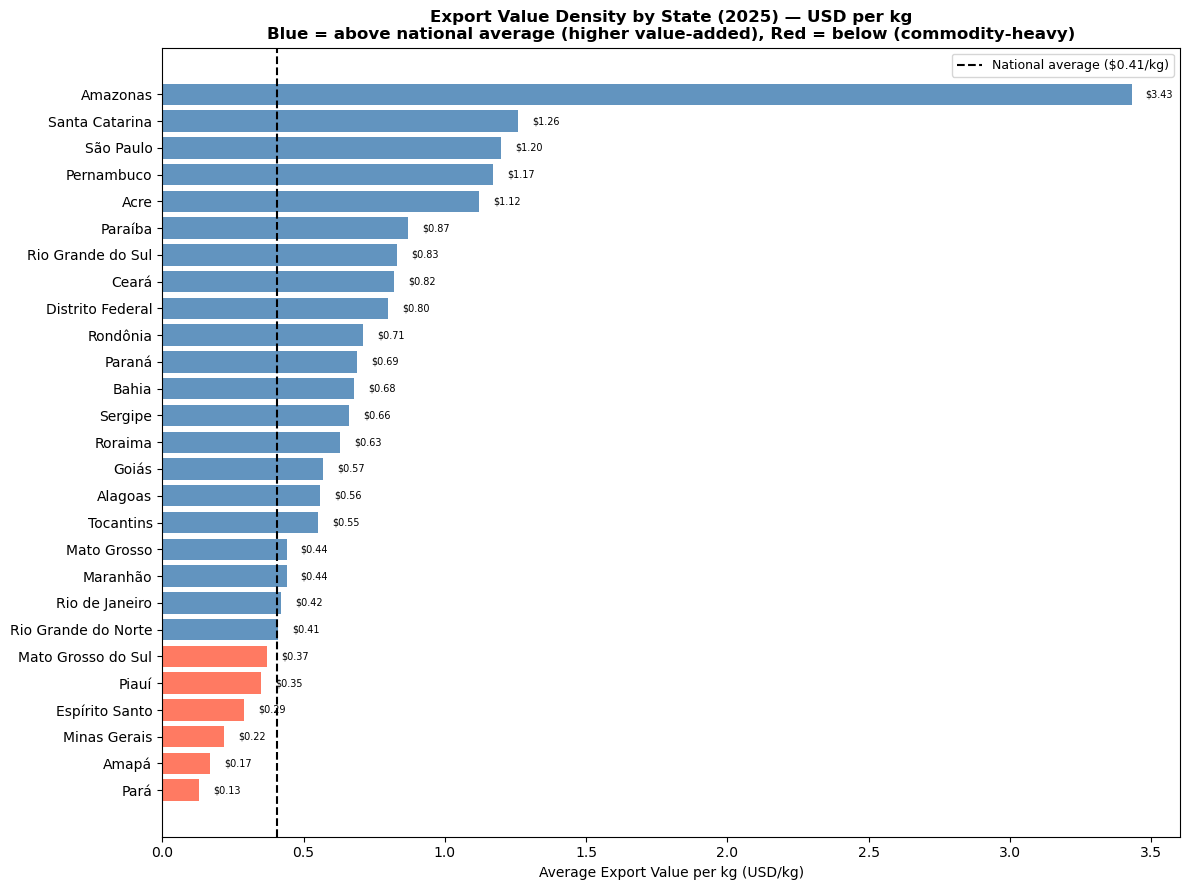


Export value density by state (2025)
National average: $0.41/kg
              state  avg_usd_per_kg
           Amazonas            3.43
     Santa Catarina            1.26
          São Paulo            1.20
         Pernambuco            1.17
               Acre            1.12
            Paraíba            0.87
  Rio Grande do Sul            0.83
              Ceará            0.82
   Distrito Federal            0.80
           Rondônia            0.71
             Paraná            0.69
              Bahia            0.68
            Sergipe            0.66
            Roraima            0.63
              Goiás            0.57
            Alagoas            0.56
          Tocantins            0.55
        Mato Grosso            0.44
           Maranhão            0.44
     Rio de Janeiro            0.42
Rio Grande do Norte            0.41
 Mato Grosso do Sul            0.37
              Piauí            0.35
     Espírito Santo            0.29
       Minas Gerais            0.22

In [36]:
## Export value density — USD per kg by state
## High ratio = high value-added exports (industrial/processed goods)
## Low ratio  = low value per kg (bulk commodity exports)
## Uses df_shipsize from 2b.5 — must run 2b.5 first

national_avg_usd_per_kg = df_shipsize['exports_usd'].sum() / df_shipsize['total_kg'].sum()

df_ratio_plot = df_shipsize.sort_values('avg_usd_per_kg', ascending=True)
colors = ['steelblue' if x >= national_avg_usd_per_kg else 'tomato'
          for x in df_ratio_plot['avg_usd_per_kg']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_ratio_plot['state'], df_ratio_plot['avg_usd_per_kg'],
        color=colors, alpha=0.85)
ax.axvline(x=national_avg_usd_per_kg, color='black', linestyle='--', linewidth=1.5,
           label=f'National average (${national_avg_usd_per_kg:.2f}/kg)')

for i, (_, row) in enumerate(df_ratio_plot.iterrows()):
    ax.text(row['avg_usd_per_kg'] + 0.05, i,
            f'${row["avg_usd_per_kg"]:.2f}',
            va='center', fontsize=7)

ax.set_title(f'Export Value Density by State ({MAX_YEAR}) — USD per kg\n'
             f'Blue = above national average (higher value-added), '
             f'Red = below (commodity-heavy)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Average Export Value per kg (USD/kg)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_2b6_usd_per_kg_ratio.png', dpi=150)
plt.show()

print(f'\nExport value density by state ({MAX_YEAR})')
print(f'National average: ${national_avg_usd_per_kg:.2f}/kg')
print(df_shipsize[['state', 'avg_usd_per_kg']]
      .sort_values('avg_usd_per_kg', ascending=False)
      .to_string(index=False))

# Export Value Density (USD/kg) — Analysis (2025)

---

## Overview

Export value density measures how much export value each state generates per kilogram shipped. It is the single most direct proxy for the commodity vs value-added divide available in this dataset — states with high USD/kg export processed, manufactured or high-value agricultural goods; states with low USD/kg export heavy bulk commodities where weight far exceeds value.

**National average: \\$0.41/kg**
**Range: \\$0.13/kg (Pará) to \\$3.43/kg (Amazonas)**

Amazonas generates 26 times more export value per kg than Pará. No other single metric in Step 2b captures the structural divide between Brazil's industrial and commodity export states as clearly as this ratio.

---

## Key Findings

### Above National Average (USD/kg > \\$0.41)

**Amazonas (\\$3.43/kg)** — the highest value density in Brazil by a wide margin, more than 2.7 times higher than the second-place state. This is entirely driven by the Zona Franca de Manaus — electronics, motorcycles and manufactured consumer goods generate high value relative to their weight. Amazonas is the only Norte state above the national average and the only state to exceed \\$2.00/kg.

**Santa Catarina (\\$1.26/kg) and São Paulo (\\$1.20/kg)** — the two most industrially diversified states in Brazil sit almost identically in second and third place. Both export a mix of machinery, food products, chemicals and manufactured goods that generate consistent value per kg across their diversified product baskets.

**Pernambuco (\\$1.17/kg)** — the highest value density among Nordeste states, substantially above the regional pattern. Pernambuco's port infrastructure (Suape), pharmaceutical and food processing industries likely drive the higher unit value. This is the most significant outlier in the Nordeste group.

**Acre (\\$1.12/kg)** — surprisingly high for a small, remote Norte state. With only 745 transactions and \\$0.10bn in total exports, the high USD/kg likely reflects a small number of high-value niche exports (possibly specialty timber, organic products or pharmaceutical ingredients) rather than a developed industrial base.

> ⚠️ *Acre's high USD/kg (\\$1.12) combined with very low total export value (\\$0.10bn) and low frequency (745 transactions) warrants product-level investigation. High value density on a very small export base may reflect statistical concentration in one or two high-value products rather than genuine industrial competitiveness.*

**Paraíba (\\$0.87/kg)** — above average value density consistent with its footwear manufacturing profile (RCA 100.97). Leather footwear generates moderate value per kg relative to bulk commodities.

**Rio Grande do Sul (\\$0.83/kg) and Ceará (\\$0.82/kg)** — both above average. Rio Grande do Sul's diversified agro-industrial base (food processing, machinery, chemicals) supports consistent value density. Ceará's result continues to be analytically interesting — above average value density combined with high ESI (1.59) and moderate HHI (0.289) suggests a cluster of moderately valued processed goods rather than a single high-value product.

**Distrito Federal (\\$0.80/kg)** — above average but with minimal export volume. As noted previously, the Federal District's export metrics are not structurally meaningful given the negligible scale.

**Rondônia (\\$0.71/kg) and Paraná (\\$0.69/kg)** — both above average. Rondônia's result is higher than expected for a Norte state and may reflect timber processing or agricultural commodity value-addition. Paraná's result is consistent with its diversified agro-industrial profile.

**Bahia (\\$0.68/kg)** — above average, consistent with its diversified export base (petrochemicals, cocoa, automotive). The Camaçari petrochemical complex generates relatively high value per kg compared to raw mineral exports.

**Sergipe (\\$0.66/kg)** — above average despite mineral fuel exports. Liquid hydrocarbons generate moderate value density — higher than iron ore or soybeans but lower than manufactured goods.

---

### At or Below National Average (USD/kg ≤ \\$0.41)

**Goiás (\\$0.57/kg), Alagoas (\\$0.56/kg) and Tocantins (\\$0.55/kg)** — all moderately below average. Goiás's soybean and beef profile, Alagoas's sugar dominance and Tocantins's agricultural frontier exports all generate moderate value density — above the ultra-bulk mineral states but below the industrial tier.

**Mato Grosso (\\$0.44/kg) and Maranhão (\\$0.44/kg)** — both just above the national average. Mato Grosso's soybean dominance generates surprisingly close to the national average value density — soybeans are relatively valuable agricultural commodities compared to iron ore. Maranhão's result reflects a mix of soybeans (through Itaqui port) and iron ore (Carajás railway exports).

**Rio de Janeiro (\\$0.42/kg)** — marginally above the national average despite oil and gas dominance. This seems counterintuitive — oil should generate high value per kg — but reflects the reporting of crude oil exports in very large weight quantities that dilute the per-kg value. Processed petroleum products would generate higher USD/kg than crude.

**Rio Grande do Norte (\\$0.41/kg)** — exactly at the national average. The combination of fruit exports (relatively high value) and salt/mineral exports (very low value) averages out precisely to the national benchmark.

**Mato Grosso do Sul (\\$0.37/kg) and Piauí (\\$0.35/kg)** — below average agricultural commodity states. Both export primarily soybeans and animal feed products at bulk commodity price levels.

**Espírito Santo (\\$0.29/kg)** — below average despite being a mid-sized exporter (\\$10.51bn). Iron ore exports through the port of Vitória (linked to Vale's Carajás operations via the Estrada de Ferro Vitória a Minas) dominate and drive down the per-kg value substantially.

**Minas Gerais (\\$0.22/kg)** — the second lowest value density among states with significant export volumes. Iron ore and steel dominate — both are extremely heavy relative to their market value. Despite being Brazil's second largest exporter by value (\\$45.83bn), Minas Gerais generates only \\$0.22 per kg shipped.

**Amapá (\\$0.17/kg)** — near the bottom, consistent with timber and primary agricultural exports. Low value, high weight.

**Pará (\\$0.13/kg)** — the lowest value density in Brazil. Iron ore from the Carajás complex is the defining export — one of the heaviest and lowest unit-value commodities in global trade. Pará ships more tonnes than almost any other state while generating relatively modest value per unit of weight.

---

## Regional Pattern

| Region | Avg USD/kg | Interpretation |
|---|---|---|
| REGIAO NORTE | ~\\$0.87/kg | Pulled up by Amazonas (\\$3.43) — without Amazonas the region average falls to ~\\$0.44 |
| REGIAO SUL | ~\\$0.93/kg | Consistently above average across all three states |
| REGIAO SUDESTE | ~\\$1.09/kg | Wide range — Amazonas effect in Norte mirrors São Paulo effect here |
| REGIAO NORDESTE | ~\\$0.72/kg | Pernambuco (\\$1.17) and Ceará (\\$0.82) pull the average above national |
| REGIAO CENTRO OESTE | ~\\$0.55/kg | Predominantly below average agricultural commodity states |

> ⚠️ *The Norte regional average is heavily distorted by Amazonas. Removing Amazonas from the Norte calculation drops the regional average from ~\\$0.87/kg to approximately \\$0.44/kg — just above the national average and driven primarily by Rondônia and Sergipe rather than any structural industrial competitiveness in the region.*

---

## Cross-Cutting Observations

**The commodity-industrial divide maps almost perfectly onto the USD/kg ranking.** States in the top half of the ranking are predominantly industrial or agro-processing; states in the bottom half are predominantly bulk commodity exporters. This metric provides the cleanest single-variable separation of export profile types in the entire Step 2b analysis.

**The national average of \\$0.41/kg is almost exactly at the commodity-industrial boundary.** States above \\$0.41/kg tend to export processed, manufactured or high-value agricultural goods. States below tend to export heavy bulk commodities. Rio de Janeiro (\\$0.42/kg) and Rio Grande do Norte (\\$0.41/kg) sit exactly at this boundary.

**São Paulo and Santa Catarina sharing near-identical USD/kg (\\$1.20 vs \\$1.26)** mirrors the ESI finding where both states scored 0.874. Two different paths to the same value density — São Paulo through industrial scale, Santa Catarina through diversified mid-size manufacturing.

**Pernambuco (\\$1.17/kg) is the most important Nordeste finding.** It sits alongside São Paulo and Santa Catarina in value density — a Nordeste state generating industrial-level value per kg. This is not captured in any of the other indicators and warrants specific attention in Step 5 when product-level analysis is available.

> ⚠️ *Requires further investigation (Step 5): What specific products drive Pernambuco's above-average value density (\\$1.17/kg)? The Suape industrial complex and pharmaceutical sector are the likely candidates but this requires NCM-level confirmation.*

> ⚠️ *Requires further investigation (Step 14 — Commodities vs Processed): The USD/kg ranking provides a preview of what the commodity vs processed classification will show once the classification table is built. States below \\$0.41/kg are strong candidates for commodity classification; states above \\$0.80/kg are strong candidates for processed/industrial classification.*


## 2b.7 — Logistics Profile Summary: Bulk vs High-Frequency Exporters
Combining shipment frequency, average shipment size and unit price to classify each state's logistics profile. States with large average shipments and low unit price are bulk commodity exporters. States with small average shipments and high unit price are high-frequency value-added exporters.

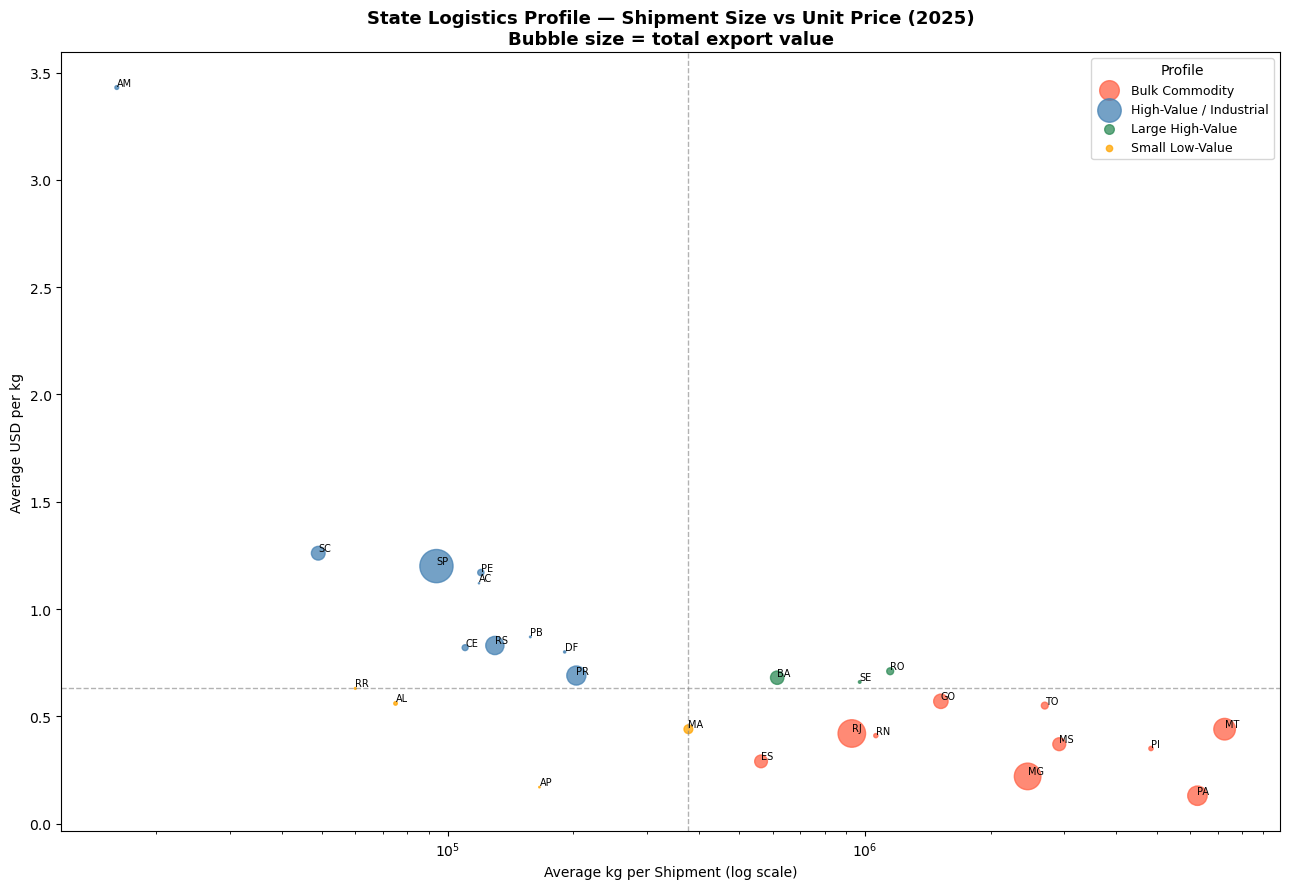


State logistics profile classification (2025)
Median avg kg/shipment: 377,095 | Median avg USD/kg: $0.63
              state              region                 profile  exports_usd_bn  avg_kg_per_shipment  avg_usd_per_kg    hhi
          Tocantins        REGIAO NORTE          Bulk Commodity            3.05            2696422.0            0.55 0.3418
     Rio de Janeiro      REGIAO SUDESTE          Bulk Commodity           48.98             929460.0            0.42 0.6985
       Minas Gerais      REGIAO SUDESTE          Bulk Commodity           45.83            2453172.0            0.22 0.1585
     Espírito Santo      REGIAO SUDESTE          Bulk Commodity           10.51             563167.0            0.29 0.1620
               Pará        REGIAO NORTE          Bulk Commodity           24.34            6262519.0            0.13 0.4365
Rio Grande do Norte     REGIAO NORDESTE          Bulk Commodity            1.13            1061155.0            0.41 0.3462
        Mato Grosso REGIAO

In [37]:
## Combine frequency and size metrics
df_logistics = df_shipsize[[
    'uf', 'state', 'exports_usd_bn', 'shipment_count',
    'avg_kg_per_shipment', 'avg_usd_per_shipment', 'avg_usd_per_kg'
]].copy()
df_logistics = df_logistics.merge(df_state[['uf', 'region']], on='uf', how='left')
df_logistics = df_logistics.merge(df_hhi_prod[['uf', 'hhi']], on='uf', how='left')

## Classify profile based on median thresholds
med_kg  = df_logistics['avg_kg_per_shipment'].median()
med_usd = df_logistics['avg_usd_per_kg'].median()

def classify_profile(row):
    high_kg  = row['avg_kg_per_shipment'] > med_kg
    high_usd = row['avg_usd_per_kg'] > med_usd
    if high_kg and not high_usd:
        return 'Bulk Commodity'
    elif not high_kg and high_usd:
        return 'High-Value / Industrial'
    elif high_kg and high_usd:
        return 'Large High-Value'
    else:
        return 'Small Low-Value'

df_logistics['profile'] = df_logistics.apply(classify_profile, axis=1)

## Scatter plot: avg kg per shipment vs avg USD per kg
profile_colors = {
    'Bulk Commodity'       : 'tomato',
    'High-Value / Industrial': 'steelblue',
    'Large High-Value'     : 'seagreen',
    'Small Low-Value'      : 'orange'
}

fig, ax = plt.subplots(figsize=(13, 9))
for profile, group in df_logistics.groupby('profile'):
    ax.scatter(
        group['avg_kg_per_shipment'],
        group['avg_usd_per_kg'],
        label=profile,
        color=profile_colors.get(profile, 'gray'),
        s=group['exports_usd_bn'] * 8,
        alpha=0.75
    )
    for _, row in group.iterrows():
        ax.annotate(row['uf'], (row['avg_kg_per_shipment'], row['avg_usd_per_kg']),
                    fontsize=7, ha='left', va='bottom')

ax.axvline(x=med_kg,  color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(y=med_usd, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Average kg per Shipment (log scale)')
ax.set_ylabel('Average USD per kg')
ax.set_xscale('log')
ax.set_title(f'State Logistics Profile — Shipment Size vs Unit Price ({MAX_YEAR})\nBubble size = total export value',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, title='Profile')
plt.tight_layout()
plt.savefig('output_2b6_logistics_scatter.png', dpi=150)
plt.show()

print(f"\nState logistics profile classification ({MAX_YEAR})")
print(f"Median avg kg/shipment: {med_kg:,.0f} | Median avg USD/kg: ${med_usd:.2f}")
print(df_logistics[['state', 'region', 'profile', 'exports_usd_bn',
                     'avg_kg_per_shipment', 'avg_usd_per_kg', 'hhi']]
      .sort_values('profile')
      .to_string(index=False))

# State Logistics Profile Classification — Analysis (2025)

---

## Overview

The logistics profile classification places each state into one of four quadrants based on two dimensions:

- **Average kg per shipment** — volume intensity (median threshold: 377,095 kg)
- **Average USD per kg** — value density (median threshold: \\$0.63/kg)

| Quadrant | kg per shipment | USD per kg | Interpretation |
|---|---|---|---|
| Bulk Commodity | Above median | Below median | High volume, low value density — heavy raw materials |
| High-Value / Industrial | Below median | Above median | Low volume, high value density — processed/manufactured goods |
| Large High-Value | Above median | Above median | High volume AND high value density — rare, mixed profile |
| Small Low-Value | Below median | Below median | Low volume AND low value density — small, underdeveloped export base |

**Distribution: 10 Bulk Commodity, 10 High-Value/Industrial, 3 Large High-Value, 4 Small Low-Value**

The near-even split between Bulk Commodity and High-Value/Industrial reflects Brazil's dual export identity — a commodity powerhouse and an emerging industrial exporter coexisting within the same national trade system.

---

## Bulk Commodity States (10 states)

The bulk commodity quadrant is dominated by Centro-Oeste agricultural states and Norte mineral states, with three Sudeste states included due to their mining profiles.

**Mato Grosso (7.3M kg, \\$0.44/kg, HHI 0.257)** — the archetypal bulk commodity state. The largest average shipment in Brazil combined with below-median value density. Soybean and corn dominance in a flat agricultural landscape designed for bulk logistics.

**Pará (6.3M kg, \\$0.13/kg, HHI 0.437)** — the lowest value density in the bulk tier. Iron ore from Carajás is one of the heaviest and lowest unit-value commodities in global trade. Pará ships enormous weight for relatively modest value per kg.

**Piauí (4.8M kg, \\$0.35/kg, HHI 0.688)** — the most concentrated state in the bulk tier. The combination of very large shipments, below-median value density and the highest HHI outside Rio de Janeiro confirms Piauí as the most structurally exposed agricultural frontier state in Brazil.

**Mato Grosso do Sul (2.9M kg, \\$0.37/kg) and Tocantins (2.7M kg, \\$0.55/kg)** — both agricultural Centro-Oeste/Norte states with bulk profiles consistent with soybean, corn and livestock exports.

**Minas Gerais (2.5M kg, \\$0.22/kg, HHI 0.159)** — the most surprising entry in the bulk tier. Despite having a relatively low HHI and a diversified export base, Minas Gerais's enormous average shipment size and very low value density place it firmly in the bulk commodity quadrant. Iron ore dominates the weight profile even when the product basket is internally more diversified.

**Espírito Santo (563k kg, \\$0.29/kg, HHI 0.162)** — similar to Minas Gerais, iron ore exports via the port of Vitória drive large average shipments and low value density despite moderate diversification.

**Goiás (1.5M kg, \\$0.57/kg, HHI 0.210)** — the closest to the median thresholds in this quadrant. Its USD/kg of \\$0.57 is just below the \\$0.63 median, placing it in bulk rather than large high-value by a narrow margin. Consistent with its soybean and beef profile.

**Rio de Janeiro (929k kg, \\$0.42/kg, HHI 0.699)** — the most analytically anomalous entry in the bulk tier. Large average shipments and below-median value density are expected from an oil and gas exporter, but the HHI of 0.699 — the highest in the dataset — combined with bulk classification confirms the unique nature of Rio de Janeiro's export profile. It is a bulk commodity state with the operational characteristics of an industrial state (high frequency, established port infrastructure) but the product concentration of a resource extraction economy.

**Rio Grande do Norte (1.1M kg, \\$0.41/kg)** — bulk classification driven by salt and fruit exports in large shipments at near-national-average value density.

---

## High-Value / Industrial States (10 states)

The high-value industrial quadrant contains Brazil's most economically diversified states alongside several smaller states whose high USD/kg reflects niche product concentration rather than genuine industrial development.

**São Paulo (94k kg, \\$1.20/kg, HHI 0.062)** — the defining industrial state. Smallest average shipment among large exporters, highest value density among high-volume states, lowest HHI in Brazil. São Paulo is the only state that is simultaneously the largest exporter, most frequent transactor and most diversified product basket.

**Santa Catarina (49k kg, \\$1.26/kg, HHI 0.154)** — the smallest average shipment in the industrial tier and the highest value density after Amazonas among the established exporters. A genuinely diversified industrial profile in container-sized lots.

**Rio Grande do Sul (130k kg, \\$0.83/kg, HHI 0.080)** and **Paraná (203k kg, \\$0.69/kg, HHI 0.099)** — both Sul states with diversified agro-industrial profiles. Paraná sits closest to the median thresholds in this quadrant — its 203k kg average is approaching the 377k median, reflecting its position as a transition state between pure industrial and mixed profiles.

**Pernambuco (120k kg, \\$1.17/kg, HHI 0.218)** — the most significant Nordeste finding. Industrial-tier value density (\\$1.17/kg) combined with below-median shipment size places it firmly in the high-value quadrant despite being a Nordeste state. The Suape industrial complex is the likely driver.

**Amazonas (16k kg, \\$3.43/kg, HHI 0.137)** — the most extreme position in the high-value quadrant. The smallest average shipment in Brazil combined with the highest value density. The Zona Franca de Manaus produces the clearest industrial-tier logistics profile in the dataset — small, frequent, high-value shipments of manufactured goods.

**Ceará (110k kg, \\$0.82/kg, HHI 0.289)** — above-median value density confirms Ceará belongs in the industrial tier. Combined with its high ESI (1.59) and moderate HHI (0.289), Ceará appears to export a cluster of processed goods that are high-value relative to their weight but structurally different from the national mix.

**Acre (119k kg, \\$1.12/kg) and Paraíba (158k kg, \\$0.87/kg)** — both classified as high-value industrial based on the median thresholds, but their small export bases (\\$0.10bn and \\$0.18bn respectively) mean this classification reflects niche product concentration rather than industrial development. The high USD/kg for these states warrants caution.

**Distrito Federal (190k kg, \\$0.80/kg)** — classified high-value industrial but with negligible export volume. Not analytically meaningful as noted throughout.

---

## Large High-Value States (3 states)

This quadrant — above-median shipment size AND above-median value density — is the rarest classification. It indicates states that ship in bulk quantities but generate above-average value per kg, suggesting either high-value bulk commodities or a mix of bulk and processed exports.

**Rondônia (1.1M kg, \\$0.71/kg, HHI 0.366)** — large shipments consistent with bulk agricultural and timber exports, but above-median value density suggests some processing or higher-value commodity mix. The HHI of 0.366 indicates moderate concentration.

**Bahia (616k kg, \\$0.68/kg, HHI 0.106)** — the most interesting Large High-Value state. Bahia combines above-median shipment size with above-median value density AND the lowest HHI among Nordeste states (0.106). This reflects the Camaçari petrochemical complex (large shipments, moderate value density) combined with cocoa and automotive exports (smaller shipments, higher value density). The blend pushes Bahia above both medians simultaneously.

**Sergipe (971k kg, \\$0.66/kg, HHI 0.477)** — mineral fuel (oil) exports generate large shipments at above-median value density. Sergipe's onshore oil production creates a large high-value profile similar in structure to Rio de Janeiro but at a much smaller scale.

---

## Small Low-Value States (4 states)

This quadrant — below-median shipment size AND below-median value density — indicates states with small, underdeveloped export bases that neither achieve the scale of bulk commodity states nor the value density of industrial states.

**Maranhão (377k kg, \\$0.44/kg, HHI 0.266)** — classified at exactly the median kg threshold. Maranhão is a borderline case — its soybean and iron ore exports through the Itaqui port generate bulk-scale shipments but below-median value density. Its classification as small low-value is marginal and reflects the median threshold placement more than a genuinely underdeveloped export base. Maranhão is the fifth largest exporter in the Nordeste (\\$5.02bn) and has meaningful port infrastructure.

> ⚠️ *Maranhão's small low-value classification should be treated with caution — it sits exactly at the median kg threshold and its \\$5.02bn export value is the largest of the four states in this quadrant by a wide margin. A small change in the median threshold would reclassify it as bulk commodity.*

**Alagoas (75k kg, \\$0.56/kg, HHI 0.559)** — small shipments and below-median value density despite high concentration. Sugar exports generate moderate value per kg but ship in smaller consignments than iron ore or soybeans. The small low-value classification reflects the limited scale and processing level of Alagoas's sugar-dominated export base.

**Roraima (60k kg, \\$0.63/kg, HHI 0.213)** — sits exactly at the USD/kg median (\\$0.63). Its classification as small low-value rather than high-value industrial is marginal. With only \\$0.24bn in exports and 6,369 transactions, Roraima's classification is driven more by small scale than structural profile.

**Amapá (166k kg, \\$0.17/kg, HHI 0.312)** — the clearest small low-value case. Below-median shipment size and the second lowest value density in Brazil (\\$0.17/kg). Timber exports generate little value per kg and the state has minimal processing capacity.

---

## Cross-Cutting Observations

**The Sudeste region splits across three quadrants** — São Paulo (high-value industrial), Minas Gerais and Espírito Santo (bulk commodity), Rio de Janeiro (bulk commodity). No other region has such internal diversity of logistics profiles, reflecting the Sudeste's combination of Brazil's industrial centre (São Paulo) and its mineral extraction heartland (Minas Gerais, Espírito Santo, Rio de Janeiro).

**The Sul region is uniformly high-value industrial** — all three states (Paraná, Rio Grande do Sul, Santa Catarina) fall in the same quadrant. This is the only region where every state shares the same logistics classification, confirming the Sul as Brazil's most structurally coherent industrial export region.

**The Centro-Oeste region is uniformly bulk commodity** — all four states (Mato Grosso, Mato Grosso do Sul, Goiás and Distrito Federal — the last excluded for scale reasons) fall in the bulk quadrant. The agricultural frontier dominates the entire region without exception.

**The Nordeste is the most internally fragmented region** — states appear in all four quadrants. Pernambuco and Ceará are high-value industrial; Bahia and Sergipe are large high-value; Alagoas and Maranhão are small low-value; Piauí and Rio Grande do Norte are bulk commodity. The Nordeste contains within itself the full spectrum of Brazilian export profiles.

| Region | Profile Distribution | Dominant Classification |
|---|---|---|
| REGIAO SUL | 3 High-Value Industrial | Uniform industrial |
| REGIAO CENTRO OESTE | 3 Bulk Commodity, 1 High-Value (DF — excluded) | Uniform bulk agricultural |
| REGIAO SUDESTE | 1 High-Value, 3 Bulk Commodity | Mixed — industrial + mining |
| REGIAO NORTE | 2 Bulk, 2 High-Value, 3 Small Low-Value | Fragmented |
| REGIAO NORDESTE | 2 Bulk, 2 High-Value, 2 Large High-Value, 2 Small Low-Value | Most fragmented |

> ⚠️ *Requires further investigation (Step 9 — Logistics): The logistics profile classification has direct implications for port infrastructure requirements. The bulk commodity tier requires deep-water bulk terminals and rail/river connections; the high-value industrial tier requires container handling capacity and multimodal logistics. Mapping the current port infrastructure against these classifications would reveal whether Brazil's logistics network is aligned with or constraining each state's export development.*


## 2b.8 — Regression Analysis: Does Shipment Size Predict Export Value Density?

Testing whether states that ship in larger average quantities (kg per transaction) 
tend to generate lower export value per kg — the physical expression of the 
commodity-industrial divide. A significant negative relationship would confirm 
that bulk shipment size is a reliable proxy for commodity dependence at the state 
level. Regression run on log scale for kg per shipment given the extreme range 
across states (16,077 kg to 7,276,112 kg). Rio de Janeiro is flagged as a 
structural outlier — crude oil generates large shipments at moderate value density, 
sitting between the bulk commodity and industrial tiers.

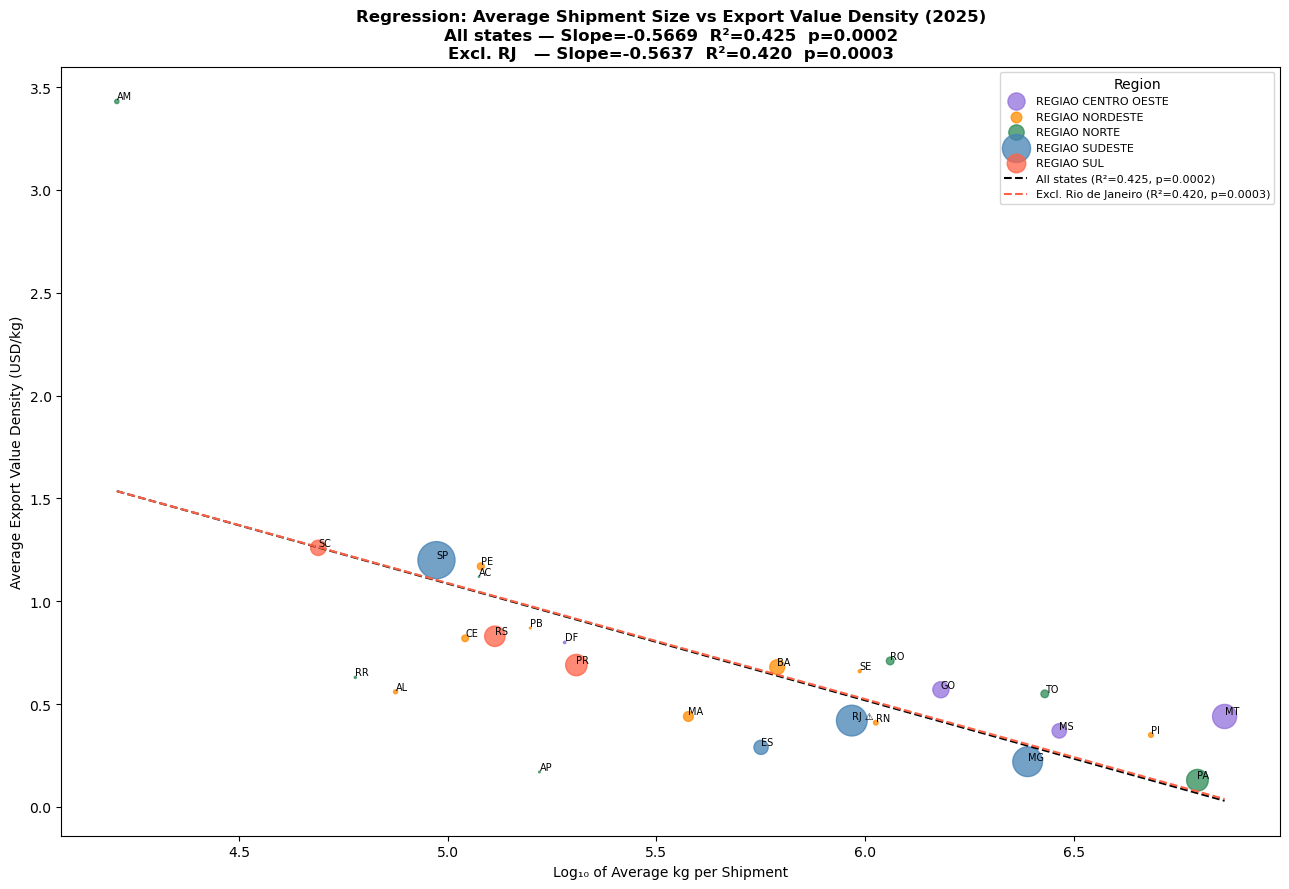


Regression Results: Log(Avg Shipment Size) vs USD/kg (2025)

  All states (n=27):
    Slope:      -0.5669
    Intercept:  3.9202
    R²:         0.4248
    p-value:    0.0002
    Std Error:  0.1319

  Excluding Rio de Janeiro (n=26):
    Slope:      -0.5637
    Intercept:  3.9068
    R²:         0.4203
    p-value:    0.0003
    Std Error:  0.1351

  Interpretation:

  All states:
    Statistically significant negative relationship (p < 0.05)
    States with larger average shipments tend to export
    lower value per kg — consistent with bulk commodity profile

  Excl. Rio de Janeiro:
    Statistically significant negative relationship (p < 0.05)
    States with larger average shipments tend to export
    lower value per kg — consistent with bulk commodity profile

Data points:
              state  avg_kg_per_shipment  avg_usd_per_kg
        Mato Grosso            7276112.0            0.44
               Pará            6262519.0            0.13
              Piauí            4846119.

In [40]:
## Regression: Log(avg kg per shipment) vs USD/kg value density
## Hypothesis: states with larger average shipments tend to have lower
## export value density — the physical signature of commodity vs industrial exports

from scipy import stats

## Uses df_shipsize from 2b.5.1
df_reg2 = df_shipsize[['uf', 'state', 'avg_kg_per_shipment', 'avg_usd_per_kg',
                        'exports_usd_bn']].copy()
df_reg2 = df_reg2.merge(df_state[['uf', 'region']], on='uf', how='left')
df_reg2 = df_reg2[~df_reg2['region'].isin(['REGIAO NAO DECLARADA'])]
df_reg2 = df_reg2[~df_reg2['state'].isin(['Não Declarada', 'Exterior'])]
df_reg2 = df_reg2[df_reg2['avg_kg_per_shipment'] > 0]
df_reg2['log_avg_kg'] = np.log10(df_reg2['avg_kg_per_shipment'])

## ---- Full regression including all states ----
slope_f, intercept_f, r_value_f, p_value_f, std_err_f = stats.linregress(
    df_reg2['log_avg_kg'], df_reg2['avg_usd_per_kg']
)
r_squared_f = r_value_f ** 2

## ---- Regression excluding Rio de Janeiro (structural outlier) ----
df_reg2_excl = df_reg2[df_reg2['state'] != 'Rio de Janeiro']
slope_e, intercept_e, r_value_e, p_value_e, std_err_e = stats.linregress(
    df_reg2_excl['log_avg_kg'], df_reg2_excl['avg_usd_per_kg']
)
r_squared_e = r_value_e ** 2

## Regression lines
x_line = np.linspace(df_reg2['log_avg_kg'].min(),
                     df_reg2['log_avg_kg'].max(), 100)
y_line_f = slope_f * x_line + intercept_f
y_line_e = slope_e * x_line + intercept_e

## Plot
region_colors_reg2 = {
    r: c for r, c in zip(
        df_reg2['region'].dropna().unique(),
        ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
    )
}

fig, ax = plt.subplots(figsize=(13, 9))

for region, group in df_reg2.groupby('region'):
    color = region_colors_reg2.get(region, 'gray')
    ax.scatter(
        group['log_avg_kg'],
        group['avg_usd_per_kg'],
        label=region,
        color=color,
        s=group['exports_usd_bn'] * 10,
        alpha=0.75,
        zorder=3
    )
    for _, row in group.iterrows():
        ## Flag Rio de Janeiro as outlier
        label = f"{row['uf']} ⚠" if row['state'] == 'Rio de Janeiro' else row['uf']
        ax.annotate(label,
                    (row['log_avg_kg'], row['avg_usd_per_kg']),
                    fontsize=7, ha='left', va='bottom')

## Both regression lines
ax.plot(x_line, y_line_f, color='black', linewidth=1.5, linestyle='--',
        label=f'All states (R²={r_squared_f:.3f}, p={p_value_f:.4f})',
        zorder=5)
ax.plot(x_line, y_line_e, color='tomato', linewidth=1.5, linestyle='--',
        label=f'Excl. Rio de Janeiro (R²={r_squared_e:.3f}, p={p_value_e:.4f})',
        zorder=5)

ax.set_title(f'Regression: Average Shipment Size vs Export Value Density ({MAX_YEAR})\n'
             f'All states — Slope={slope_f:.4f}  R²={r_squared_f:.3f}  p={p_value_f:.4f}\n'
             f'Excl. RJ   — Slope={slope_e:.4f}  R²={r_squared_e:.3f}  p={p_value_e:.4f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Log₁₀ of Average kg per Shipment')
ax.set_ylabel('Average Export Value Density (USD/kg)')
ax.legend(fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b8_regression_shipsize_density.png', dpi=150)
plt.show()

## Results summary
print(f"\nRegression Results: Log(Avg Shipment Size) vs USD/kg ({MAX_YEAR})")
print(f"\n  All states (n={len(df_reg2)}):")
print(f"    Slope:      {slope_f:.4f}")
print(f"    Intercept:  {intercept_f:.4f}")
print(f"    R²:         {r_squared_f:.4f}")
print(f"    p-value:    {p_value_f:.4f}")
print(f"    Std Error:  {std_err_f:.4f}")
print(f"\n  Excluding Rio de Janeiro (n={len(df_reg2_excl)}):")
print(f"    Slope:      {slope_e:.4f}")
print(f"    Intercept:  {intercept_e:.4f}")
print(f"    R²:         {r_squared_e:.4f}")
print(f"    p-value:    {p_value_e:.4f}")
print(f"    Std Error:  {std_err_e:.4f}")
print(f"\n  Interpretation:")
for label, slope, p_value, r_sq in [
    ('All states',            slope_f, p_value_f, r_squared_f),
    ('Excl. Rio de Janeiro',  slope_e, p_value_e, r_squared_e)
]:
    print(f"\n  {label}:")
    if p_value < 0.05:
        direction = "negative" if slope < 0 else "positive"
        print(f"    Statistically significant {direction} relationship (p < 0.05)")
        if slope < 0:
            print(f"    States with larger average shipments tend to export")
            print(f"    lower value per kg — consistent with bulk commodity profile")
    else:
        print(f"    No statistically significant relationship (p >= 0.05)")

print(f"\nData points:")
print(df_reg2[['state', 'avg_kg_per_shipment', 'avg_usd_per_kg']]
      .sort_values('avg_kg_per_shipment', ascending=False)
      .to_string(index=False))

# Regression Analysis: Average Shipment Size vs Export Value Density (2025)

---

## Model Summary

| Metric | All States (n=27) | Excl. Rio de Janeiro (n=26) |
|---|---|---|
| Slope | -0.5669 | -0.5637 |
| Intercept | 3.9202 | 3.9068 |
| R² | 0.4248 | 0.4203 |
| p-value | 0.0002 | 0.0003 |
| Std Error | 0.1319 | 0.1351 |

**Result: Statistically significant negative relationship in both specifications (p < 0.001)**

---

## Key Results

### R² of 0.425 — the strongest regression in Step 2b

This regression explains 42.5% of the variation in export value density from shipment size alone — significantly stronger than the frequency-HHI regression (R² = 0.192 single year, 0.336 pooled). The physical characteristics of what states export — heavy bulk commodities vs light manufactured goods — predict value density more reliably than operational frequency predicts product concentration.

### Rio de Janeiro is not an outlier here

The most striking result is the near-identical output with and without Rio de Janeiro:

- R² changes by only 0.005 (0.4248 → 0.4203)
- Slope changes by only 0.003 (-0.5669 → -0.5637)
- Both remain highly significant

This is the opposite of what was expected. Rio de Janeiro behaves consistently with the regression line in this specification — crude oil exports generate large shipments (929k kg average) at below-median value density (\\$0.42/kg), which is exactly what the model predicts for a state at that shipment size. The outlier behaviour identified in the frequency-HHI regression was specific to the frequency dimension (high transactions despite high concentration) not to the physical shipment dimension.

> ⚠️ *Rio de Janeiro is only an outlier in the frequency-HHI relationship, not in the shipment size-value density relationship. This clarifies the nature of Rio de Janeiro's anomaly — its oil export operations generate many transactions (frequency outlier) but each transaction is physically large and low value per kg (consistent with the commodity regression). The distinction matters for any logistics or competitiveness assessment.*

---

## Interpretation of the Slope

The slope of -0.5669 means that for every unit increase in log₁₀ of average kg per shipment, USD/kg decreases by approximately \\$0.57. In practical terms:

Moving from Amazonas (16,077 kg average, log = 4.21) to Mato Grosso (7,276,112 kg average, log = 6.86) — a log difference of 2.65 — the model predicts a USD/kg reduction of approximately \\$1.50. The actual difference is \\$3.43 - \\$0.44 = \\$2.99, confirming the direction strongly but indicating Amazonas is above the regression line (higher value density than the model predicts for its shipment size) and Mato Grosso is close to the line.

---

## Data Point Analysis

### States Close to the Regression Line
These states confirm the expected commodity-industrial gradient:

| State | Avg kg | USD/kg | Profile |
|---|---|---|---|
| Mato Grosso | 7,276,112 | \\$0.44 | Large bulk agricultural — on the line |
| Paraná | 203,171 | \\$0.69 | Mid-scale industrial — on the line |
| Rio Grande do Sul | 129,585 | \\$0.83 | Diversified industrial — on the line |
| São Paulo | 93,867 | \\$1.20 | Industrial — slightly above line |
| Piauí | 4,846,119 | \\$0.35 | Agricultural frontier — on the line |

### Notable Deviations Above the Regression Line
States generating more value per kg than their shipment size would predict:

**Amazonas (\\$3.43/kg)** — the furthest above the regression line in the dataset. The Zona Franca de Manaus manufactured goods generate dramatically more value per kg than the regression predicts for a state with 16,077 kg average shipments. This confirms Amazonas as a structural outlier in the value density dimension — its manufactured goods profile is anomalous for a Norte state.

**Pernambuco (\\$1.17/kg, 120k kg avg)** — above the regression line, generating more value per kg than the model predicts for its shipment size. Consistent with the Suape industrial complex hypothesis.

**Rondônia (\\$0.71/kg, 1.1M kg avg)** — above the regression line for its kg level, suggesting a higher-value commodity mix than pure iron ore or grain states of similar shipment size.

### Notable Deviations Below the Regression Line
States generating less value per kg than their shipment size would predict:

**Pará (\\$0.13/kg, 6.3M kg avg)** — the furthest below the regression line. Despite having the second largest average shipments, Pará generates much less value per kg than Mato Grosso at similar shipment sizes. Iron ore (Pará's dominant export) generates dramatically less value per kg than soybeans (Mato Grosso's dominant export), even though both are bulk commodities.

**Minas Gerais (\\$0.22/kg, 2.5M kg avg)** — below the line. Iron ore dominance drives value density lower than the model predicts for its shipment size category.

**Espírito Santo (\\$0.29/kg, 563k kg avg)** — below the line, also iron ore driven via the port of Vitória.

**Amapá (\\$0.17/kg, 166k kg avg)** — significantly below the line. Timber exports generate very low value per kg despite relatively small average shipments. Amapá is the only small-shipment state with near-zero value density.

---

## Comparison with the Frequency-HHI Regression

| Metric | Frequency vs HHI (2025) | Shipment Size vs USD/kg |
|---|---|---|
| R² | 0.192 | 0.425 |
| p-value | 0.022 | 0.0002 |
| Primary outlier | Rio de Janeiro (frequency) | Amazonas (value density) |
| RJ outlier impact | Large (removes from analysis) | Negligible (R² drops only 0.005) |
| Mechanism | Operational profile | Physical commodity characteristics |

The shipment size-value density regression is stronger on every statistical metric. This makes economic sense — the physical weight-to-value ratio of a commodity is a more mechanically determined property than the relationship between how often a state transacts and how concentrated its product basket is.

---

## Conclusion

Average shipment size (log scale) explains 42.5% of the variation in export value density across Brazilian states — the strongest single-predictor relationship identified in Step 2b. The relationship is highly significant (p = 0.0002), robust to the exclusion of Rio de Janeiro, and directionally consistent with the commodity-industrial divide observed across all other metrics in this notebook.

The two key deviations from the regression line are analytically the most valuable findings:

1. **Amazonas above the line** — the Zona Franca de Manaus generates anomalously high value density relative to its physical shipment profile, confirming that the Free Trade Zone creates a structurally distinct export identity within the Norte region
2. **Pará below the line** — iron ore generates lower value per kg than soybeans even at similar shipment scales, confirming that not all bulk commodity states are equivalent in value generation capacity

> ⚠️ *The combined evidence from both regressions (frequency-HHI and shipment size-USD/kg) now provides a two-dimensional characterisation of each state's export structure. A state's position on both regression lines simultaneously — above or below in each — provides a richer competitiveness signal than either metric alone. This two-dimensional framework could be formalised in the Key Findings section as a state classification tool.*


## 2b.9 — Key Findings: Advanced State Competitiveness Indicators (2025)

---

## Overview

Step 2b extends the state-level trade analysis from Step 2 into structural competitiveness metrics — moving beyond what states trade and with whom, toward how competitive they are, how concentrated their product base is, and what their physical export profile reveals about their position in global value chains.

Six analytical lenses were applied across all 27 Brazilian states:
1. Revealed Comparative Advantage (RCA) — sector-level competitive strengths
2. Export Specialisation Index (ESI) — deviation from the national export mix
3. Product Concentration Index (HHI) — within-state sector concentration
4. Export Frequency — number of transactions as an operational proxy
5. Shipment Size and Value Density — physical export profile (kg and USD/kg)
6. Regression Analysis — structural relationships between these indicators

---

## Finding 1 — The Commodity-Industrial Divide is Brazil's Defining Export Structure

Every metric in Step 2b — RCA, ESI, HHI, frequency, shipment size and value density — converges on the same structural divide. Brazilian states fall into two broad categories that are consistent across all indicators:

**Industrial / Diversified states:** São Paulo, Rio Grande do Sul, Santa Catarina, Paraná, Bahia, Minas Gerais (partial), Amazonas (Free Trade Zone driven)

**Commodity / Concentrated states:** Mato Grosso, Pará, Piauí, Alagoas, Rio de Janeiro, Espírito Santo, Mato Grosso do Sul, Tocantins

The Sul region is the only region where every state falls in the industrial category across all metrics. The Centro-Oeste is the only region where every state falls in the commodity category. All other regions contain states from both sides of the divide.

---

## Finding 2 — Rio de Janeiro is Brazil's Most Structurally Anomalous Export State

Rio de Janeiro appears as an outlier in more metrics than any other state:

- **Highest HHI in Brazil (0.699)** — the most concentrated large exporter
- **Highest ESI among large exporters (1.363)** — most specialised relative to national mix
- **Outlier in the frequency-HHI regression** — high transaction frequency despite extreme product concentration
- **Consistent with regression in the shipment size-value density model** — crude oil generates large shipments at below-median value density as expected
- **RCA profile dominated by a single sector** — mineral fuels (RCA 5.18, \\$40.79bn)

The oil and gas sector creates a unique export identity that does not map cleanly onto either the industrial or commodity classification. Rio de Janeiro has the operational characteristics of an industrial state (125k transactions, established port infrastructure) but the product concentration of a resource extraction economy. This distinction is important for any market entry or investment assessment.

> ⚠️ *Rio de Janeiro's export concentration in oil and gas represents the single largest commodity risk in Brazil's state-level trade profile. Energy transition risk and commodity price volatility would disproportionately impact a state that generates \\$48.98bn in exports through a single SH2 chapter.*

---

## Finding 3 — The Sul Region is Brazil's Most Structurally Coherent Export Region

Across every metric in Step 2b, the three Sul states — Paraná, Rio Grande do Sul and Santa Catarina — form a consistently distinct cluster:

| Metric | Paraná | Rio Grande do Sul | Santa Catarina |
|---|---|---|---|
| HHI | 0.099 | 0.080 | 0.154 |
| ESI | 0.846 | 0.893 | 1.278 |
| Avg USD/kg | \\$0.69 | \\$0.83 | \\$1.26 |
| Frequency | 168k | 200k | 199k |
| Logistics profile | High-Value Industrial | High-Value Industrial | High-Value Industrial |

All three states are high-frequency, low-HHI, above-median value density exporters classified in the high-value industrial quadrant. No other region achieves this level of internal consistency across all indicators. The Sul region collectively defines the industrial export pole of Brazil.

Santa Catarina's ESI of 1.278 is the only outlier within the group — it deviates from the national export mix more than its Sul neighbours, driven by its textile and vessel manufacturing RCA profile. However its low HHI (0.154) and high value density (\\$1.26/kg) confirm it belongs structurally in the industrial tier despite the specialisation deviation.

---

## Finding 4 — Amazonas is the Most Structurally Distinct State in Brazil

Amazonas generates \\$3.43/kg — the highest export value density in Brazil, 2.7 times higher than second-place Santa Catarina (\\$1.26/kg) and 26 times higher than Pará (\\$0.13/kg). It is the only Norte state classified as high-value industrial. It sits furthest above the regression line in the shipment size-value density model.

The Zona Franca de Manaus creates an export identity that is entirely disconnected from the geographic and natural resource context of the Norte region. Electronics, motorcycles and manufactured consumer goods generate a logistics profile (16,077 kg average shipment, \\$55k average value) that more closely resembles a European industrial exporter than a Brazilian Norte state.

> ⚠️ *Amazonas's export competitiveness is structurally dependent on the continuation of the Zona Franca de Manaus regime. Any policy change to the Free Trade Zone would fundamentally alter the state's position across all competitiveness metrics.*

---

## Finding 5 — The Regression Analyses Reveal a Two-Dimensional State Classification

Two regressions were run across Step 2b:

**Regression 1 — Log(Shipment Frequency) vs HHI:**
- R² = 0.192 (single year), 0.336 (pooled 1997–2025)
- Slope = -0.0896 (2025), -0.1226 (pooled)
- States with higher frequency tend toward lower product concentration
- Rio de Janeiro is the primary outlier — high frequency, extreme concentration
- Relationship weakened post-2015 and broke down during COVID-19 (2020–2023)

**Regression 2 — Log(Avg Shipment Size) vs USD/kg:**
- R² = 0.425
- Slope = -0.5669
- States with larger average shipments tend toward lower value density
- Rio de Janeiro is NOT an outlier — crude oil fits the model
- Amazonas is the primary outlier — anomalously high value density for its shipment size

The two regressions together provide a richer characterisation of each state's export structure than either alone. A state's position above or below both regression lines simultaneously defines a two-dimensional competitive profile:

| Position | Freq-HHI | Size-Density | Interpretation |
|---|---|---|---|
| Above both lines | Higher freq than HHI predicts | Higher value than size predicts | Strong industrial overperformer |
| Below both lines | Lower freq than HHI predicts | Lower value than size predicts | Commodity underperformer |
| Above Freq-HHI, below Size-Density | Operationally active, physically heavy | Mixed — processing with bulk logistics |
| Below Freq-HHI, above Size-Density | Infrequent but high-value | Niche high-value commodity or specialised manufacturer |

---

## Finding 6 — The Post-2015 Weakening of the Frequency-Concentration Relationship

The year-by-year regression (1997–2025) reveals two structural breaks:

**Break 1 — Post-2015 weakening (gradual):**
The regression slope weakened from approximately -0.138 (1997–2015 average) to approximately -0.089 (2016–2025 average). This predates COVID-19 and likely reflects the MATOPIBA agricultural frontier expansion — new soybean-producing states (Piauí, Maranhão, Tocantins) increased export value without proportionally increasing transaction frequency, compressing the frequency gap between agricultural and industrial states.

**Break 2 — COVID-19 structural break (2020–2023):**
Four consecutive non-significant years centred on the pandemic. The relationship between frequency and concentration lost statistical significance entirely during this period. Supply chain disruptions disproportionately reduced industrial state transaction volumes while commodity exports continued relatively undisrupted — temporarily equalising the frequency profiles of commodity and industrial states.

The relationship has been recovering since 2024 (p = 0.034) and 2025 (p = 0.022) but remains below pre-COVID strength.

> ⚠️ *Any analysis of the frequency-concentration relationship using data from 2020–2023 alone would produce unreliable results. The pooled regression (R² = 0.336, n = 844) is the most reliable estimate of the structural relationship.*

---

## Finding 7 — The Nordeste is Brazil's Most Internally Heterogeneous Region

The Nordeste contains states across all four logistics profile quadrants simultaneously — a finding not replicated in any other region:

- **Bulk Commodity:** Piauí (HHI 0.688, \\$0.35/kg), Rio Grande do Norte
- **High-Value Industrial:** Pernambuco (\\$1.17/kg), Ceará (\\$0.82/kg)
- **Large High-Value:** Bahia (\\$0.68/kg, HHI 0.106), Sergipe
- **Small Low-Value:** Alagoas (HHI 0.559), Maranhão

Pernambuco and Alagoas — neighbouring states — are at opposite ends of the value density ranking (\\$1.17/kg vs \\$0.56/kg). Any Nordeste-level generalisation about Brazil's export competitiveness will mask this internal heterogeneity. Pernambuco's industrial profile (Suape complex) is as different from Alagoas's sugar monoculture as São Paulo is from Mato Grosso.

---

## Finding 8 — High RCA Does Not Imply High Export Value

The RCA analysis revealed a systematic pattern across both the top 10 and bottom 10 exporting states: the highest RCA values are frequently found in sectors with negligible export volumes.

**Most extreme examples:**
- Paraíba: footwear RCA 100.97 — \\$0.05bn in exports
- Roraima: cereal preparations RCA 81.55 — \\$0.02bn in exports
- Amapá: timber RCA 54.90 — \\$0.07bn in exports
- Santa Catarina: specialised fabrics RCA 18.99 — \\$0.02bn in exports

This is partly a mathematical artefact — when national market shares in a sector are very small, even a modest state presence generates a high RCA ratio. Results above RCA 10 with export values below \\$0.1bn should be treated with particular caution.

The most economically significant RCA findings are those combining high RCA with material export value: Minas Gerais coffee (RCA 5.48, \\$11.29bn), Pará iron ore (RCA 6.45, \\$15.73bn), Mato Grosso soybeans (RCA 3.40, \\$13.17bn) and São Paulo aerospace (RCA 4.53, \\$4.54bn).

---

## Limitations

**Sample size:** 27 states is a small dataset for regression analysis. The pooled panel regression (n=844) substantially mitigates this concern but single-year results should be interpreted with caution.

**Frequency as proxy:** Row count per state is a proxy for shipment count, not an official transaction register. Liquid bulk commodities (oil, liquid chemicals) may generate transaction records at a different granularity than solid bulk or containerised goods.

**RCA at SH2 level:** Calculating RCA at the 2-digit sector level aggregates significant product diversity within each chapter. SH4 or NCM-level RCA would provide more precise competitive advantage identification but at substantially higher computational cost.

**Single year for most metrics:** ESI, HHI, frequency and shipment size were calculated for 2025 only. A multi-year panel equivalent to the frequency-HHI regression would provide more robust estimates for all indicators.

**Commodity classification pending:** The commodity vs processed goods classification (cell 2.14) remains incomplete pending the construction of the NCM classification table. Several findings in this notebook — particularly the USD/kg boundary at \\$0.41/kg — provide a preliminary framework for that classification.

---

## What Comes Next

**Step 3 — Municipality-Level Hotspots:** Disaggregating the state-level findings to the municipality level to identify the specific cities and industrial clusters driving each state's export profile.

**Step 5 — Product Complexity and Diversification:** NCM-level product analysis to explain the ESI and HHI findings — particularly Ceará's anomalous ESI, Pernambuco's high value density and the RCA artefact problem in small states.

**Step 9 — Logistics:** Mapping the logistics profile classification against actual port infrastructure by state — testing whether current infrastructure matches or constrains each state's export development trajectory.

**Step 14 — Commodities vs Processed Products:** The USD/kg boundary at \\$0.41/kg and the logistics profile quadrants provide a preliminary framework for the commodity classification that will be built in this step once the NCM classification table is available.
